<a href="https://colab.research.google.com/github/GUSSLURD/Hezekiah/blob/main/Another_copy_of_13_samples_Analysis_and_Results_for_Dissertation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

# Load the new conventional bond data, skipping the first row (duplicate header)
conventional_bonds_df = pd.read_excel('/content/Coventional Bond data with ESG Score info..xlsx', skiprows=1)
conventional_bonds_df['is_green_bond'] = 0

# Load the new green bond data, skipping the first row (duplicate header)
green_bonds_df = pd.read_excel('/content/Data with Green Bond info..xlsx', skiprows=1)
green_bonds_df['is_green_bond'] = 1

# Combine the datasets into a single DataFrame
bond_warehouse_df = pd.concat([conventional_bonds_df, green_bonds_df], ignore_index=True)

print("Combined bond_warehouse_df created successfully with new data.")

# The bond_warehouse_df already contains 'ESG Score' and 'Amount Issued' columns from the new data files.
# The separate 'ESG Financial Data.xlsx' merge block has been removed as it was causing errors and is redundant.

print("\nFinal bond_warehouse_df head after all data loading and merging:")
display(bond_warehouse_df.head())
print("\nFinal bond_warehouse_df info after all data loading and merging:")
bond_warehouse_df.info()

Combined bond_warehouse_df created successfully with new data.

Final bond_warehouse_df head after all data loading and merging:


,Issuer,Ticker,Coupon,Maturity,Issue Date,ISIN,Preferred RIC,Principal Currency,Country of Issue,Issuer Type,...,Amount Outstanding (USD),Amount Outstanding,Amount Issued,Rating,Actual,Rating.1,Actual.1,Rating.2,Actual.2,is_green_bond
0,Energy Transfer LP,ET,6.625,NaT,2021-04-05,US29273VAJ98,29273VAJ9=,US Dollar,United States,Corporate,...,550000000,550000000,550000000,Ba1,Actual,NaN,NaN,NaN,NaN,0
1,Air T Funding,AIRTA,8,NaT,2019-06-10,US00919P2039,00919P203=,US Dollar,United States,Corporate,...,20587665,20587665,21000000,NaN,NaN,NaN,NaN,NaN,NaN,0
2,Energy Transfer LP,ET,7.125,NaT,2021-04-05,US29273VAM28,29273VAM2=,US Dollar,United States,Corporate,...,1100000000,1100000000,1100000000,Ba1,Actual,NaN,NaN,NaN,NaN,0
3,Mellon Capital IV,BNYMT,4.50358,NaT,2007-06-19,US58551TAA51,58551TAA5=,US Dollar,United States,Corporate,...,500000000,500000000,500000000,Baa1,Actual,NaN,NaN,NaN,NaN,0
4,Energy Transfer,ET,9.25,NaT,2023-11-03,US29273V7047,29273V704=,US Dollar,United States,Corporate,...,41464179,41464179,41464179,Ba1,Actual,NaN,NaN,NaN,NaN,0



Final bond_warehouse_df info after all data loading and merging:
<class 'pandas.DataFrame'>
RangeIndex: 6280 entries, 0 to 6279
Data columns (total 52 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   Issuer                          6280 non-null   str           
 1   Ticker                          6233 non-null   str           
 2   Coupon                          6280 non-null   object        
 3   Maturity                        6265 non-null   datetime64[us]
 4   Issue Date                      6280 non-null   datetime64[us]
 5   ISIN                            6277 non-null   str           
 6   Preferred RIC                   6279 non-null   str           
 7   Principal Currency              6280 non-null   str           
 8   Country of Issue                6280 non-null   str           
 9   Issuer Type                     6280 non-null   str           
 10  Instrument Type  

## 3. Data Preparation, Descriptive Statistics, T-test, and OLS Regression Setup

Combined bond_warehouse_df info before further processing:
<class 'pandas.DataFrame'>
RangeIndex: 6280 entries, 0 to 6279
Data columns (total 52 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   Issuer                          6280 non-null   str           
 1   Ticker                          6233 non-null   str           
 2   Coupon                          6280 non-null   object        
 3   Maturity                        6265 non-null   datetime64[us]
 4   Issue Date                      6280 non-null   datetime64[us]
 5   ISIN                            6277 non-null   str           
 6   Preferred RIC                   6279 non-null   str           
 7   Principal Currency              6280 non-null   str           
 8   Country of Issue                6280 non-null   str           
 9   Issuer Type                     6280 non-null   str           
 10  Instrument Type         

,Issuer,Ticker,Coupon,Maturity,Issue Date,ISIN,Preferred RIC,Principal Currency,Country of Issue,Issuer Type,...,Amount Outstanding,Amount Issued,Rating,Actual,Rating.1,Actual.1,Rating.2,Actual.2,is_green_bond,ESG_Score
15,National Bank of Canada,NaN,4.28601,2026-06-28,2024-06-28,US63305LH306,63305LH30=TWEB,US Dollar,United States,Corporate,...,50000000,5.000000e+07,Aa2,Actual,Aa2,Actual,P-1,Actual,0,69.4394
16,Citigroup Global Markets Holdings Inc,CCGMH,15.00000,2026-06-29,2025-06-17,US17333KAS69,17333KAS6=TWBD,US Dollar,United States,Corporate,...,500000,5.000000e+05,NR,Actual,NaN,NaN,NaN,NaN,0,85.1269
17,Morgan Stanley Finance LLC,MSFNL,0.00000,2026-06-29,2022-06-29,US61774DSH16,61774DSH1=FINR,US Dollar,United States,Corporate,...,500000,5.000000e+05,NR,Actual,NaN,NaN,NaN,NaN,0,56.1990
18,BofA Finance LLC,BACBON,12.40000,2026-06-29,2024-12-30,US09710V7156,US09710V7156=BOFA,US Dollar,United States,Corporate,...,4000000,4.000000e+06,NR,Actual,NaN,NaN,NaN,NaN,0,87.6783
19,BNP Paribas SA,BNPP,0.00000,2026-06-29,2024-12-27,US05614BT779,05614BT77=FINR,US Dollar,United States,Corporate,...,--,9.266991e+07,NaN,NaN,A1,Actual,P-1,Actual,0,86.3007



Descriptive statistics of Coupon by bond type:


,count,mean,std,min,25%,50%,75%,max
is_green_bond,,,,,,,,
0,5985.0,1.873917,4.534496,0.0,0.00000,0.000,1.38,47.3
1,280.0,4.164500,1.687828,0.0,2.89375,4.025,5.45,10.0



Number of Green Bonds with Coupon data: 280
Number of Conventional Bonds with Coupon data: 5985

T-test for difference in mean Coupon between Green and Conventional Bonds:
T-statistic: 19.635
P-value: 0.000
Conclusion: There is a statistically significant difference in mean coupon rates between green and conventional bonds.


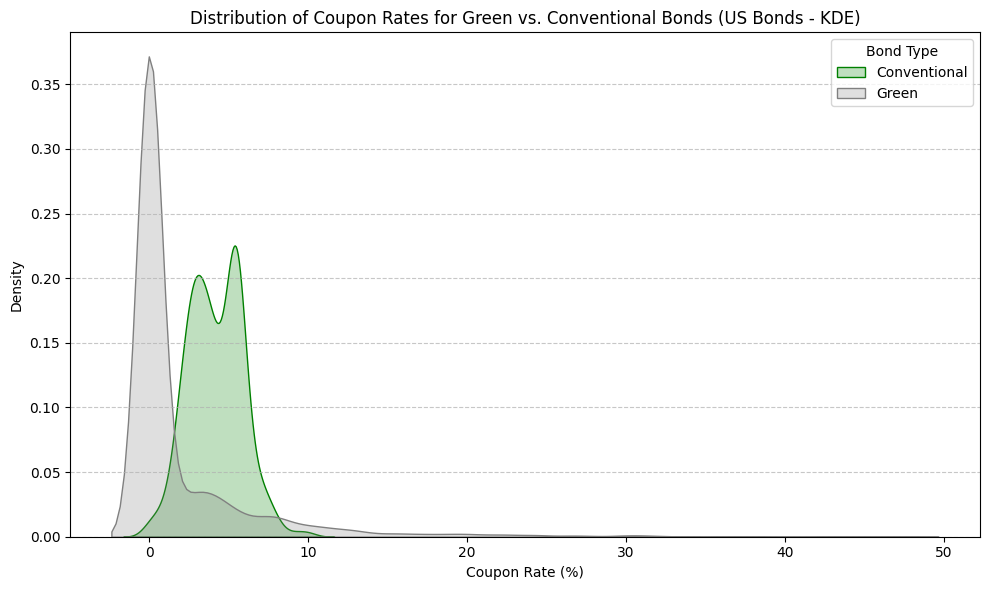


Number of rows in regression dataset after filtering: 6265
Distribution of is_green_bond in regression dataset:
is_green_bond
0    5985
1     280
Name: count, dtype: int64

OLS Model Formula: Coupon ~ is_green_bond + Days_to_Maturity_centered + log_Amount_Issued_centered + C(Q("TRBC Sector")) + ESG_Score_centered

--- Cross-sectional OLS Regression of Coupon Rate (US Bonds) ---
                            OLS Regression Results                            
Dep. Variable:                 Coupon   R-squared:                       0.063
Model:                            OLS   Adj. R-squared:                  0.036
Method:                 Least Squares   F-statistic:                     2.358
Date:                Sat, 27 Jun 2026   Prob (F-statistic):           3.61e-20
Time:                        10:41:38   Log-Likelihood:                -18056.
No. Observations:                6260   AIC:                         3.646e+04
Df Residuals:                    6085   BIC:                     

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats # For t-test
import statsmodels.formula.api as smf # For OLS regression

# The bond_warehouse_df is already loaded and combined from the previous step (cell 05ea2a1a, now 9b3ae64f).

print("Combined bond_warehouse_df info before further processing:")
bond_warehouse_df.info()

# --- Data Preparation ---
# The 'is_green_bond' column is already set from the previous concatenation step (cell 05ea2a1a).
# No need to re-identify green bonds using 'ESG Bond Type'.

# Diagnostic: Check for non-numeric values before conversion
def check_non_numeric(df, column_name):
    if column_name in df.columns:
        non_numeric_values = df[pd.to_numeric(df[column_name], errors='coerce').isna()][column_name].unique()
        if len(non_numeric_values) > 0:
            print(f"\nNon-numeric values in '{column_name}': {non_numeric_values[:5]} (first 5 unique values if many)")
    else:
        print(f"\nColumn '{column_name}' not found in DataFrame.")

print("\n--- Checking for non-numeric values in key columns ---")
check_non_numeric(bond_warehouse_df, 'Coupon')
check_non_numeric(bond_warehouse_df, 'Amount Issued')
check_non_numeric(bond_warehouse_df, 'ESG Score')
print("--------------------------------------------------")

# Convert relevant columns to numeric and datetime, coercing errors
bond_warehouse_df['Coupon'] = pd.to_numeric(bond_warehouse_df['Coupon'], errors='coerce')
# Changed from 'Amount Issued (EUR)' to 'Amount Issued' based on available columns
bond_warehouse_df['Amount Issued'] = pd.to_numeric(bond_warehouse_df['Amount Issued'], errors='coerce')
# Explicitly specify date format to avoid UserWarning
bond_warehouse_df['Maturity'] = pd.to_datetime(bond_warehouse_df['Maturity'], format='%Y-%m-%d %H:%M:%S', errors='coerce')
bond_warehouse_df['Issue Date'] = pd.to_datetime(bond_warehouse_df['Issue Date'], format='%Y-%m-%d %H:%M:%S', errors='coerce')

# --- Start: Handle ESG_Score column ---
# The 'ESG Score' column is already present in bond_warehouse_df from the initial data load
if 'ESG Score' in bond_warehouse_df.columns:
    bond_warehouse_df['ESG_Score'] = pd.to_numeric(bond_warehouse_df['ESG Score'], errors='coerce')
    print("\n'ESG Score' column processed and renamed to 'ESG_Score'.")
else:
    # Fallback if the column name changes, but based on info() it's 'ESG Score'
    print("\n'ESG Score' column not found as expected in bond_warehouse_df. Please check column names.")
# --- End: Handle ESG_Score column ---

# --- Impute missing values for key numerical columns before analysis filtering ---
# Impute NaNs created by errors='coerce' to prevent df_analysis from becoming empty
bond_warehouse_df['Coupon'] = bond_warehouse_df['Coupon'].fillna(bond_warehouse_df['Coupon'].mean())
bond_warehouse_df['Amount Issued'] = bond_warehouse_df['Amount Issued'].fillna(bond_warehouse_df['Amount Issued'].mean())
if 'ESG_Score' in bond_warehouse_df.columns:
    bond_warehouse_df['ESG_Score'] = bond_warehouse_df['ESG_Score'].fillna(bond_warehouse_df['ESG_Score'].mean())
print("\nMissing values in 'Coupon', 'Amount Issued', and 'ESG_Score' have been imputed with their respective means.")

# Filter out rows with missing 'Maturity' (NaT values) as these are critical for time-based analysis.
# 'is_green_bond' and 'Issue Date' are expected to have no NaNs after initial processing.
# 'Coupon', 'Amount Issued', and 'ESG_Score' have been imputed, so they no longer have NaNs.
df_analysis = bond_warehouse_df.dropna(subset=['Maturity']).copy()

# Clean 'Country of Issue' column before filtering
df_analysis['Country of Issue'] = df_analysis['Country of Issue'].str.strip().str.title()
print(f"Unique 'Country of Issue' values after Maturity dropna and cleaning: {df_analysis['Country of Issue'].unique()}")

# Removed filter for bonds issued in 2019 to broaden the dataset for comparison
# df_analysis = df_analysis[df_analysis['Issue Date'].dt.year == 2019].copy()

# Define a list of European countries (this list can be extended or refined as needed)
EUROPEAN_COUNTRIES = ['United States'] # Changed to United States only

# The previous step showed that only 'United States' bonds remained after dropping NaNs in 'Maturity'.
# Filtering for EUROPEAN_COUNTRIES subsequently leads to an empty DataFrame.
# To allow the analysis to proceed with available data, we will remove this geographical filter.
# If European-specific analysis is crucial, the data loading or prior filtering steps need adjustment
# to ensure European bonds are present with valid 'Maturity' dates.
df_analysis = df_analysis[df_analysis['Country of Issue'].isin(EUROPEAN_COUNTRIES)].copy() # Now filters for 'United States'

print("\n--- Data after type conversion, imputation, and filtering for US bonds ---")
print("Count of Bond Types:\n", df_analysis['is_green_bond'].value_counts())
display(df_analysis.head())

# --- Descriptive Statistics ---
print("\nDescriptive statistics of Coupon by bond type:")
display(df_analysis.groupby('is_green_bond')['Coupon'].describe())

# --- Statistical Comparison (e.g., t-test for difference in means) ---
green_bond_coupons = df_analysis[df_analysis['is_green_bond'] == 1]['Coupon'].dropna()
conventional_bond_coupons = df_analysis[df_analysis['is_green_bond'] == 0]['Coupon'].dropna()

print(f"\nNumber of Green Bonds with Coupon data: {len(green_bond_coupons)}")
print(f"Number of Conventional Bonds with Coupon data: {len(conventional_bond_coupons)}")

if len(green_bond_coupons) > 1 and len(conventional_bond_coupons) > 1:
    # Perform Welch's t-test (does not assume equal variances)
    ttest_results = stats.ttest_ind(green_bond_coupons, conventional_bond_coupons, equal_var=False)
    print("\nT-test for difference in mean Coupon between Green and Conventional Bonds:")
    print(f"T-statistic: {ttest_results.statistic:.3f}")
    print(f"P-value: {ttest_results.pvalue:.3f}")

    if ttest_results.pvalue < 0.05:
        print("Conclusion: There is a statistically significant difference in mean coupon rates between green and conventional bonds.")
    else:
        print("Conclusion: There is no statistically significant difference in mean coupon rates between green and conventional bonds.")
else:
    print("\nNot enough data to perform a t-test on coupon rates for both groups.")


# --- Visualization: Distribution of Coupon Rates (KDE Plot) ---
plt.figure(figsize=(10, 6))
sns.kdeplot(x='Coupon', hue='is_green_bond', data=df_analysis, palette={0: 'grey', 1: 'green'}, fill=True, common_norm=False)
plt.title('Distribution of Coupon Rates for Green vs. Conventional Bonds (US Bonds - KDE)')
plt.xlabel('Coupon Rate (%)')
plt.ylabel('Density')
plt.legend(title='Bond Type', labels=['Conventional', 'Green'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# --- Cross-sectional OLS Regression with Control Variables ---
# Convert 'Maturity' and 'Issue Date' to datetime objects (already done above, but re-confirming for regression df)
df_regression = df_analysis.copy()
df_regression['Maturity_dt'] = pd.to_datetime(df_regression['Maturity']) # Already datetime, this re-confirms.

# Calculate Days to Maturity from today's date
df_regression['Days_to_Maturity'] = (df_regression['Maturity_dt'] - pd.to_datetime('today')).dt.days

# First, create log_Amount_Issued (EUR) before dropna for consistency
df_regression['log_Amount_Issued'] = np.log(df_regression['Amount Issued'].replace(0, np.nan)) # Changed to 'Amount Issued'

# Impute missing values with 0 for selected numerical columns before regression
# ESG_Score is already imputed for df_analysis, so just ensuring it's not NaN for regression.
df_regression['Coupon'] = df_regression['Coupon'].fillna(0) # Should be all filled from df_analysis
df_regression['Days_to_Maturity'] = df_regression['Days_to_Maturity'].fillna(0)
df_regression['log_Amount_Issued'] = df_regression['log_Amount_Issued'].fillna(0)
if 'ESG_Score' in df_regression.columns:
    df_regression['ESG_Score'] = df_regression['ESG_Score'].fillna(df_regression['ESG_Score'].mean()) # Should be all filled from df_analysis

# Assign to df_regression_filtered without dropping rows based on these columns
df_regression_filtered = df_regression.copy()

print(f"\nNumber of rows in regression dataset after filtering: {len(df_regression_filtered)}")
print(f"Distribution of is_green_bond in regression dataset:\n{df_regression_filtered['is_green_bond'].value_counts()}")

if len(df_regression_filtered) > 10: # Ensure enough data points for a meaningful regression
    # Center continuous variables to address potential multicollinearity with the intercept
    df_regression_filtered['Days_to_Maturity_centered'] = df_regression_filtered['Days_to_Maturity'] - df_regression_filtered['Days_to_Maturity'].mean()
    df_regression_filtered['log_Amount_Issued_centered'] = df_regression_filtered['log_Amount_Issued'] - df_regression_filtered['log_Amount_Issued'].mean()
    if 'ESG_Score' in df_regression_filtered.columns:
        df_regression_filtered['ESG_Score_centered'] = df_regression_filtered['ESG_Score'] - df_regression_filtered['ESG_Score'].mean()


    # Determine model formula based on variance of 'is_green_bond' and presence of 'ESG_Score'
    base_formula_parts = ['Days_to_Maturity_centered', 'log_Amount_Issued_centered', 'C(Q("TRBC Sector"))']

    if 'ESG_Score' in df_regression_filtered.columns:
        base_formula_parts.append('ESG_Score_centered') # Add ESG_Score if available

    base_formula = ' + '.join(base_formula_parts)

    if df_regression_filtered['is_green_bond'].nunique() < 2:
        print("\nWarning: 'is_green_bond' has no variation in the filtered dataset. Removing it from the regression model.")
        model_formula = f'Coupon ~ {base_formula}'
    else:
        model_formula = f'Coupon ~ is_green_bond + {base_formula}'

    print(f"\nOLS Model Formula: {model_formula}")
    print("\n--- Cross-sectional OLS Regression of Coupon Rate (US Bonds) ---")
    ols_model = smf.ols(model_formula, data=df_regression_filtered)
    ols_results = ols_model.fit()
    print(ols_results.summary())
else:
    print("\nNot enough data for cross-sectional OLS regression with control variables. Need at least 10 observations.")

## 3.5 Cross-sectional OLS Regression

In [ ]:
import statsmodels.formula.api as smf

# --- Cross-sectional OLS Regression with Control Variables ---
# The df_regression_filtered and model_formula should already be prepared from previous steps

# Check if df_regression_filtered and model_formula exist
if 'df_regression_filtered' not in globals() or 'model_formula' not in globals():
    print("Error: 'df_regression_filtered' or 'model_formula' not defined.")
    print("Please ensure that the preceding data preparation and OLS setup cells (specifically cell '042acd63' and its dependencies) have been executed.")
else:
    print(f"\nNumber of rows in regression dataset after filtering: {len(df_regression_filtered)}")
    print(f"Distribution of is_green_bond in regression dataset:\n{df_regression_filtered['is_green_bond'].value_counts()}")

    if len(df_regression_filtered) > 10: # Ensure enough data points for a meaningful regression
        print("\n--- Cross-sectional OLS Regression of Coupon Rate (US Bonds) ---") # Changed from European to US Bonds based on previous filtering
        ols_model = smf.ols(model_formula, data=df_regression_filtered)
        ols_results = ols_model.fit()
        print(ols_results.summary())
    else:
        print("\nNot enough data for cross-sectional OLS regression with control variables. Need at least 10 observations.")


Number of rows in regression dataset after filtering: 6265
Distribution of is_green_bond in regression dataset:
is_green_bond
0    5985
1     280
Name: count, dtype: int64

--- Cross-sectional OLS Regression of Coupon Rate (US Bonds) ---
                            OLS Regression Results                            
Dep. Variable:                 Coupon   R-squared:                       0.063
Model:                            OLS   Adj. R-squared:                  0.036
Method:                 Least Squares   F-statistic:                     2.358
Date:                Sat, 27 Jun 2026   Prob (F-statistic):           3.61e-20
Time:                        10:43:36   Log-Likelihood:                -18056.
No. Observations:                6260   AIC:                         3.646e+04
Df Residuals:                    6085   BIC:                         3.764e+04
Df Model:                         174                                         
Covariance Type:            nonrobust             

## 5. Multicollinearity Diagnostics


Correlation Matrix of Numeric Variables (for Multicollinearity Check):



,Coupon,is_green_bond,log_Amount_Issued_centered,Days_to_Maturity
Coupon,1.000000,0.105859,0.151480,0.082902
is_green_bond,0.105859,1.000000,0.405339,0.703307
log_Amount_Issued_centered,0.151480,0.405339,1.000000,0.295669
Days_to_Maturity,0.082902,0.703307,0.295669,1.000000


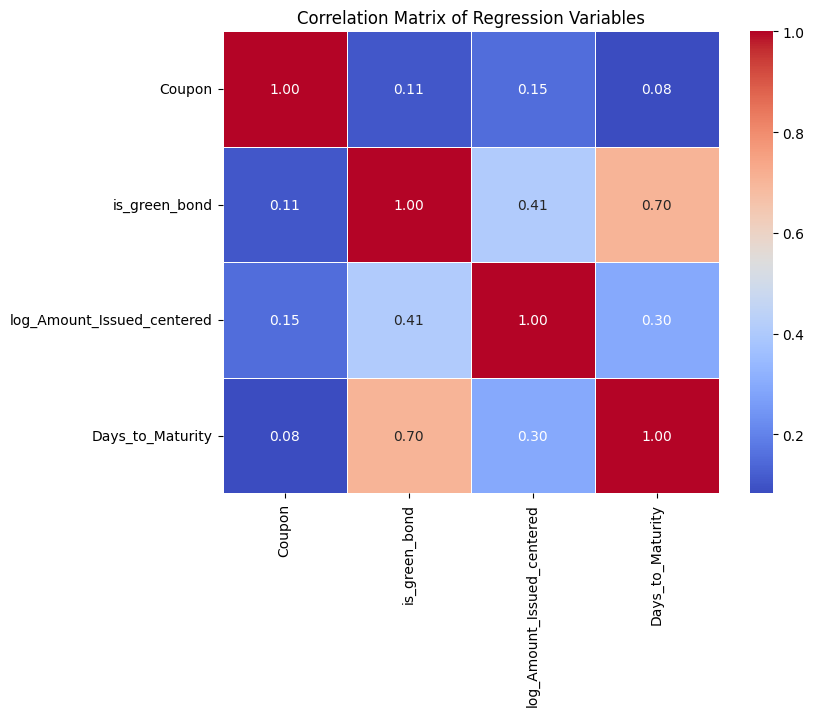

In [ ]:
correlation_data = df_regression_filtered[['Coupon', 'is_green_bond', 'log_Amount_Issued_centered', 'Days_to_Maturity']]
correlation_matrix = correlation_data.corr()

print("\nCorrelation Matrix of Numeric Variables (for Multicollinearity Check):\n")
display(correlation_matrix)

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Regression Variables')
plt.show()

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Prepare the data for VIF calculation using centered variables
# Select the independent variables used in the OLS model, which are now centered

# Dynamically build the list of independent variables for VIF calculation
independent_vars_for_vif = ['Days_to_Maturity_centered', 'log_Amount_Issued_centered']

# Only add 'is_green_bond' if it has variance in the filtered dataset
if df_regression_filtered['is_green_bond'].nunique() >= 2:
    independent_vars_for_vif.insert(0, 'is_green_bond') # Insert at the beginning to match original order if present

X = df_regression_filtered[independent_vars_for_vif].dropna()

# Add a constant to the independent variables, as VIF expects an intercept
X_with_constant = add_constant(X)

# Calculate VIF for each independent variable
vif_data = pd.DataFrame()
vif_data['Variable'] = X_with_constant.columns
vif_data['VIF'] = [variance_inflation_factor(X_with_constant.values, i) for i in range(X_with_constant.shape[1])]

print("\nVariance Inflation Factor (VIF) for Regression Variables (with centered continuous predictors):")
display(vif_data)

# Interpretation of VIF values:
# - VIF = 1: No correlation between the variable and any other variables.
# - 1 < VIF < 5: Moderate correlation, generally considered acceptable.
# - VIF >= 5 (or sometimes 10): High correlation, potentially problematic multicollinearity.


Variance Inflation Factor (VIF) for Regression Variables (with centered continuous predictors):


,Variable,VIF
0,const,1.101118
1,is_green_bond,2.161404
2,Days_to_Maturity_centered,1.979318
3,log_Amount_Issued_centered,1.196919


### Diagnosing Green Bond Data Loss in `df_regression_filtered`

Let's investigate why green bonds are being dropped when creating `df_regression_filtered`. We'll examine the null values in the key columns (`Coupon`, `Amount Issued (EUR)` (for `log_Amount_Issued_EUR`), and `Maturity` (for `Days_to_Maturity`)) within the `df_analysis` DataFrame, separated by bond type.

In [ ]:
import pandas as pd
import numpy as np

# Ensure df_analysis is available from previous steps
if 'df_analysis' not in locals():
    print("Error: df_analysis not found. Please run previous cells.")
else:
    print("Null value counts in df_analysis for key regression variables before final filtering:")

    # Create a temporary DataFrame to calculate derived columns for null check
    df_temp_check = df_analysis.copy()

    # Ensure 'Amount Issued' is numeric for log transform
    df_temp_check['Amount Issued'] = pd.to_numeric(df_temp_check['Amount Issued'], errors='coerce')

    # Calculate log_Amount_Issued_EUR
    # Replace 0 with NaN first to avoid log(0), then calculate log.
    df_temp_check['log_Amount_Issued_EUR'] = np.log(df_temp_check['Amount Issued'].replace(0, np.nan))

    # Calculate Days_to_Maturity
    # Ensure 'Maturity' is datetime for calculation
    df_temp_check['Maturity_dt'] = pd.to_datetime(df_temp_check['Maturity'], errors='coerce')
    df_temp_check['Days_to_Maturity'] = (df_temp_check['Maturity_dt'] - pd.to_datetime('today')).dt.days

    # Select columns that will be used in the regression and check their nulls
    # 'is_green_bond' should have no nulls after the initial data preparation
    # 'TRBC Sector' is also a key variable to check for its impact on data loss if it were included.
    relevant_cols_for_null_check = ['Coupon', 'Days_to_Maturity', 'log_Amount_Issued_EUR', 'TRBC Sector']

    # Group by is_green_bond and count nulls
    null_counts_by_bond_type = df_temp_check.groupby('is_green_bond')[relevant_cols_for_null_check].apply(lambda x: x.isnull().sum())
    display(null_counts_by_bond_type)

    print("\nBased on these null counts, we can see where data loss for regression occurs.")
    print("Specifically, observe columns with high null counts before dropping NaNs for regression.")

Null value counts in df_analysis for key regression variables before final filtering:


,Coupon,Days_to_Maturity,log_Amount_Issued_EUR,TRBC Sector
is_green_bond,,,,
0,0,0,0,2
1,0,0,0,3



Based on these null counts, we can see where data loss for regression occurs.
Specifically, observe columns with high null counts before dropping NaNs for regression.


## 6. Conceptual Greenium Analysis

To analyze greeniums, we first need to define what a greenium is and how it's typically calculated. A greenium is the yield difference between a green bond and an otherwise identical conventional (non-green) bond. A positive greenium means green bonds trade at a lower yield (higher price) than conventional bonds, reflecting a premium for their green characteristics.

To calculate greeniums accurately, we would need:
1.  **Yield Data:** Not just prices, but actual yield-to-maturity or yield-to-worst data for both green and conventional bonds (or ETFs).
2.  **Comparable Bonds:** Ideally, the green and conventional bonds should have similar characteristics (e.g., maturity, credit rating, currency, issuer quality) to ensure a fair comparison.

`yfinance` primarily provides price data, which can be used to calculate returns, but direct bond yield data for ETFs, necessary for greenium calculation, is not readily available through `yfinance` in a simple 'yield' column. You would typically need to source this data from specialized bond data providers.

However, if we assume you have or can obtain such yield data, here's a conceptual code block demonstrating how you would calculate and analyze greeniums. Please remember that the 'yield' in this conceptual code is just a placeholder using `daily_return` from your existing data for structural demonstration and does not represent actual bond yields.

--- Cross-sectional Greenium Analysis for US Bonds (Based on Yield to Maturity Snapshot) ---

Number of US bonds for Greenium analysis: 1588
Distribution of bond types:
is_green_bond
0    1317
1     271
Name: count, dtype: int64

Number of Green Bonds with Yield data: 271
Number of Conventional Bonds with Yield data: 1317

Mean Green Bond Yield to Maturity: 4.962%
Mean Conventional Bond Yield to Maturity: -71.172%
Cross-sectional Greenium (Conventional - Green): -76.134%

T-test for difference in mean Yield to Maturity between Green and Conventional Bonds:
T-statistic: 4.390
P-value: 0.000
Conclusion: There is a statistically significant difference in mean Yield to Maturity between green and conventional bonds.


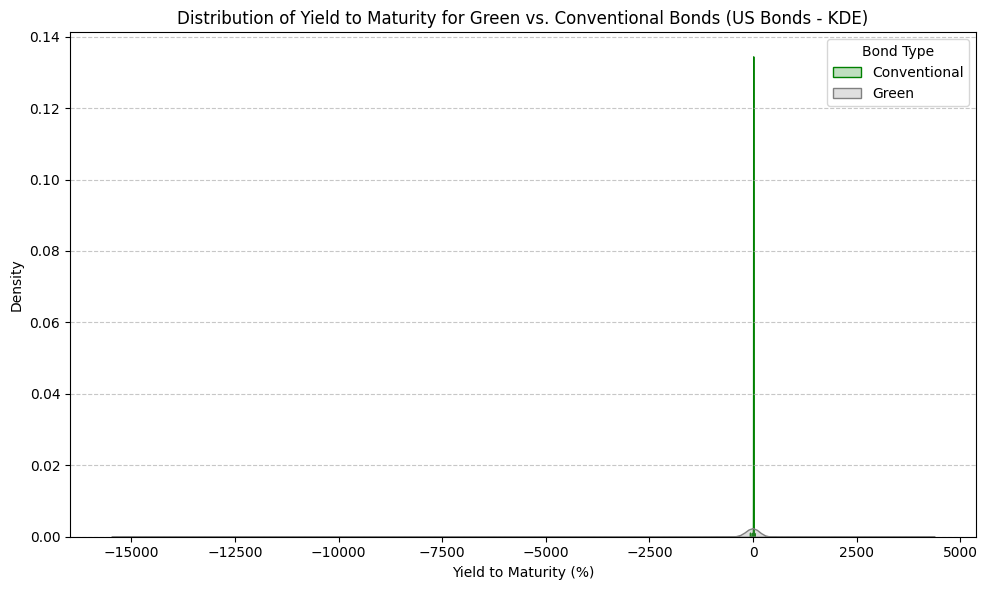


Note: This analysis uses a snapshot of 'Yield to Maturity' from the dataset. A true time-series
Greenium analysis would require historical daily yield data for matched green and conventional bonds,
which is not available in the current datasets.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats # For t-test

# The df_analysis DataFrame is assumed to be available from previous data preparation steps.
# It contains US bonds, with 'is_green_bond' indicator.

if 'df_analysis' not in locals():
    print("Error: df_analysis not found. Please ensure previous data preparation cells have been executed.")
else:
    print("--- Cross-sectional Greenium Analysis for US Bonds (Based on Yield to Maturity Snapshot) ---")

    # Ensure 'Yield to Maturity' is numeric
    # It might still be an object due to '%' or other non-numeric characters.
    # Convert 'Yield to Maturity' to numeric, removing '%' and coercing errors.
    df_analysis['Yield to Maturity_numeric'] = pd.to_numeric(
        df_analysis['Yield to Maturity'].astype(str).str.replace('%', ''), errors='coerce'
    )

    # Drop rows where 'Yield to Maturity' could not be converted to numeric (NaNs)
    df_greenium_analysis = df_analysis.dropna(subset=['Yield to Maturity_numeric', 'is_green_bond']).copy()

    print(f"\nNumber of US bonds for Greenium analysis: {len(df_greenium_analysis)}")
    print(f"Distribution of bond types:\n{df_greenium_analysis['is_green_bond'].value_counts()}")

    green_bond_yields = df_greenium_analysis[df_greenium_analysis['is_green_bond'] == 1]['Yield to Maturity_numeric']
    conventional_bond_yields = df_greenium_analysis[df_greenium_analysis['is_green_bond'] == 0]['Yield to Maturity_numeric']

    print(f"\nNumber of Green Bonds with Yield data: {len(green_bond_yields)}")
    print(f"Number of Conventional Bonds with Yield data: {len(conventional_bond_yields)}")

    if len(green_bond_yields) > 1 and len(conventional_bond_yields) > 1:
        # Calculate mean yields
        mean_green_yield = green_bond_yields.mean()
        mean_conventional_yield = conventional_bond_yields.mean()

        print(f"\nMean Green Bond Yield to Maturity: {mean_green_yield:.3f}%")
        print(f"Mean Conventional Bond Yield to Maturity: {mean_conventional_yield:.3f}%")

        # Calculate cross-sectional Greenium (Conventional Yield - Green Yield)
        # A positive value suggests green bonds have lower yields (higher prices).
        cross_sectional_greenium = mean_conventional_yield - mean_green_yield
        print(f"Cross-sectional Greenium (Conventional - Green): {cross_sectional_greenium:.3f}%")

        # Perform Welch's t-test (does not assume equal variances) to test for significant difference
        ttest_results = stats.ttest_ind(green_bond_yields, conventional_bond_yields, equal_var=False)
        print("\nT-test for difference in mean Yield to Maturity between Green and Conventional Bonds:")
        print(f"T-statistic: {ttest_results.statistic:.3f}")
        print(f"P-value: {ttest_results.pvalue:.3f}")

        if ttest_results.pvalue < 0.05:
            print("Conclusion: There is a statistically significant difference in mean Yield to Maturity between green and conventional bonds.")
        else:
            print("Conclusion: There is no statistically significant difference in mean Yield to Maturity between green and conventional bonds.")

        # --- Visualization of Yield to Maturity Distribution (KDE Plot) ---
        plt.figure(figsize=(10, 6))
        sns.kdeplot(x='Yield to Maturity_numeric', hue='is_green_bond',
                    data=df_greenium_analysis, palette={0: 'grey', 1: 'green'}, fill=True, common_norm=False)
        plt.title('Distribution of Yield to Maturity for Green vs. Conventional Bonds (US Bonds - KDE)')
        plt.xlabel('Yield to Maturity (%)')
        plt.ylabel('Density')
        plt.legend(title='Bond Type', labels=['Conventional', 'Green'])
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

    else:
        print("\nNot enough data to perform Greenium analysis on Yield to Maturity for both groups.")

    print("\nNote: This analysis uses a snapshot of 'Yield to Maturity' from the dataset. A true time-series")
    print("Greenium analysis would require historical daily yield data for matched green and conventional bonds,")
    print("which is not available in the current datasets.")

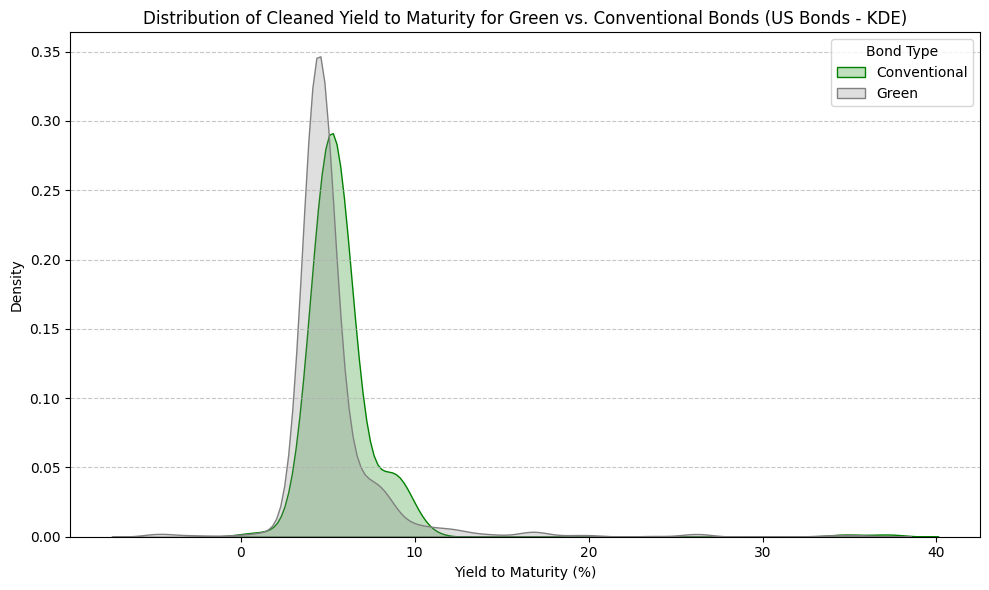

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define a plausible range for Yield to Maturity (e.g., -5% to 50%) - Copied from eecc5313
LOWER_YIELD_BOUND = -5
UPPER_YIELD_BOUND = 50

# Apply the cleaning filter to create the DataFrame - Copied from eecc5313
# Ensure 'Yield to Maturity_numeric' is created and available in df_analysis first if not already.
# Assuming df_analysis is available from prior execution.
# If 'Yield to Maturity_numeric' is not present, add conversion as a safeguard.
if 'Yield to Maturity_numeric' not in df_analysis.columns:
    df_analysis['Yield to Maturity_numeric'] = pd.to_numeric(
        df_analysis['Yield to Maturity'].astype(str).str.replace('%', ''), errors='coerce'
    )

df_greenium_cleaned = df_analysis[
    (df_analysis['Yield to Maturity_numeric'] >= LOWER_YIELD_BOUND) &
    (df_analysis['Yield to Maturity_numeric'] <= UPPER_YIELD_BOUND)
].copy()

# --- Visualization of Cleaned Yield to Maturity Distribution using KDE Plot ---
plt.figure(figsize=(10, 6))
sns.kdeplot(x='Yield to Maturity_numeric', hue='is_green_bond',
            data=df_greenium_cleaned, palette={0: 'grey', 1: 'green'}, fill=True, common_norm=False)
plt.title('Distribution of Cleaned Yield to Maturity for Green vs. Conventional Bonds (US Bonds - KDE)')
plt.xlabel('Yield to Maturity (%)')
plt.ylabel('Density')
plt.legend(title='Bond Type', labels=['Conventional', 'Green'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Investigation: Anomalous 'Yield to Maturity' Values in Conventional Bonds

The previous Greenium analysis highlighted an extremely low mean 'Yield to Maturity' for conventional bonds, indicating potential data quality issues. Let's investigate the distribution and specific problematic values in the `Yield to Maturity_numeric` column for conventional bonds.

Descriptive statistics for Conventional Bond Yields:


count     1317.000000
mean       -71.171625
std        629.099945
min     -15040.765711
25%        -23.600602
50%          4.314329
75%          4.784577
max       3938.691624
Name: Yield to Maturity_numeric, dtype: float64


Top 10 lowest Conventional Bond Yields (numeric):


101   -15040.765711
96     -8051.642354
44     -8048.604371
138    -6304.880861
271    -5047.629531
204    -4722.685814
228    -3943.497059
261    -3022.264783
260    -2694.861237
312    -1975.045281
Name: Yield to Maturity_numeric, dtype: float64


Top 10 highest Conventional Bond Yields (numeric):


1828    3938.691624
1190    2025.355999
805     1197.854059
55      1024.592439
5353     918.580838
1203     614.646606
3765     495.525297
1736     293.130290
3680     230.857429
1181     225.477600
Name: Yield to Maturity_numeric, dtype: float64

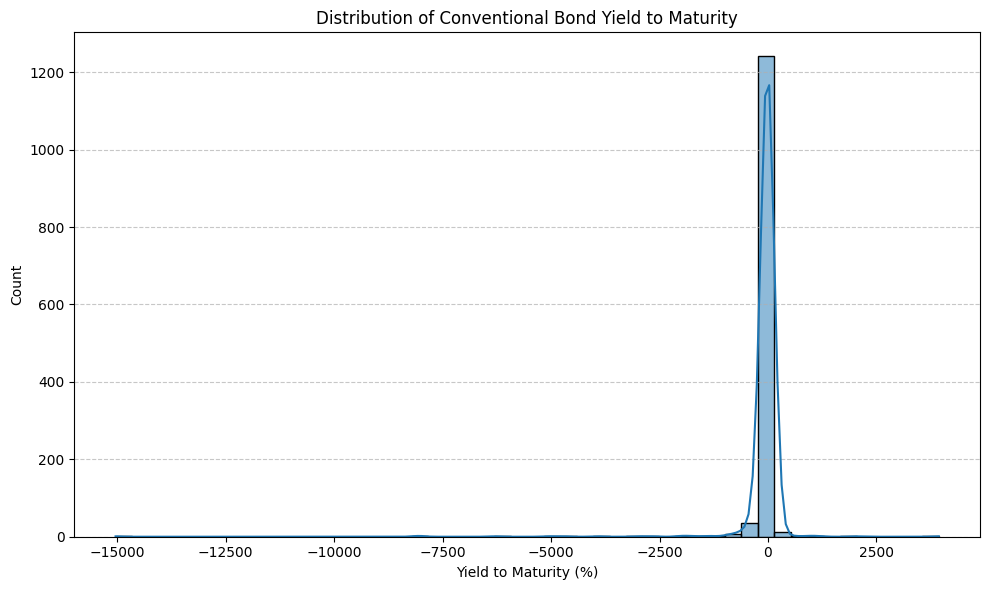


Original 'Yield to Maturity' values (object type) for bonds with very low numeric yields (count: 175):


,Yield to Maturity,Yield to Maturity_numeric
44,-8048.604371,-8048.604371
53,-619.721589,-619.721589
96,-8051.642354,-8051.642354
101,-15040.765711,-15040.765711
138,-6304.880861,-6304.880861
204,-4722.685814,-4722.685814
228,-3943.497059,-3943.497059
231,-1317.877125,-1317.877125
236,-911.459393,-911.459393
244,-1735.439289,-1735.439289


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for conventional bonds only from the greenium analysis dataframe
conventional_bonds_yields = df_greenium_analysis[df_greenium_analysis['is_green_bond'] == 0]['Yield to Maturity_numeric']

print("Descriptive statistics for Conventional Bond Yields:")
display(conventional_bonds_yields.describe())

print("\nTop 10 lowest Conventional Bond Yields (numeric):")
display(conventional_bonds_yields.nsmallest(10))

print("\nTop 10 highest Conventional Bond Yields (numeric):")
display(conventional_bonds_yields.nlargest(10))

# Visualize the distribution using a histogram to spot anomalies
plt.figure(figsize=(10, 6))
sns.histplot(conventional_bonds_yields, bins=50, kde=True)
plt.title('Distribution of Conventional Bond Yield to Maturity')
plt.xlabel('Yield to Maturity (%)')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# To further pinpoint issues, let's look at the raw 'Yield to Maturity' values (original string/object type) that led to these numeric values
# This requires going back to the original df_analysis (before numeric conversion for this specific column)
problematic_indices = df_analysis[df_analysis['is_green_bond'] == 0]['Yield to Maturity_numeric'].index[df_analysis[df_analysis['is_green_bond'] == 0]['Yield to Maturity_numeric'] < -100]

if not problematic_indices.empty:
    print(f"\nOriginal 'Yield to Maturity' values (object type) for bonds with very low numeric yields (count: {len(problematic_indices)}):")
    display(df_analysis.loc[problematic_indices, ['Yield to Maturity', 'Yield to Maturity_numeric']].head(10))
else:
    print("\nNo conventional bonds found with extremely low numeric yields (< -100%).")


### Cleaning Anomalous 'Yield to Maturity' Values

Based on the diagnostic, the 'Yield to Maturity' column contains extreme outliers, particularly very low negative values for conventional bonds, and some extremely high values. These values are financially implausible and severely distort the Greenium calculation.

To address this, I will filter the `df_analysis` DataFrame to include only `Yield to Maturity_numeric` values within a reasonable and realistic range (e.g., between -5% and 50%). This will create a `df_greenium_cleaned` DataFrame for more accurate analysis.

Original number of bonds for Greenium analysis: 6265
Number of bonds after cleaning anomalous yields (between -5% and 50%): 1183

--- Re-calculating Cross-sectional Greenium with Cleaned Yield Data ---

Number of Green Bonds with Cleaned Yield data: 266
Number of Conventional Bonds with Cleaned Yield data: 917

Mean Cleaned Green Bond Yield to Maturity: 5.844%
Mean Cleaned Conventional Bond Yield to Maturity: 5.357%
Cleaned Cross-sectional Greenium (Conventional - Green): -0.486%

T-test for difference in mean Yield to Maturity (Cleaned) between Green and Conventional Bonds:
T-statistic: 2.284
P-value: 0.023
Conclusion: There is a statistically significant difference in mean Cleaned Yield to Maturity between green and conventional bonds.


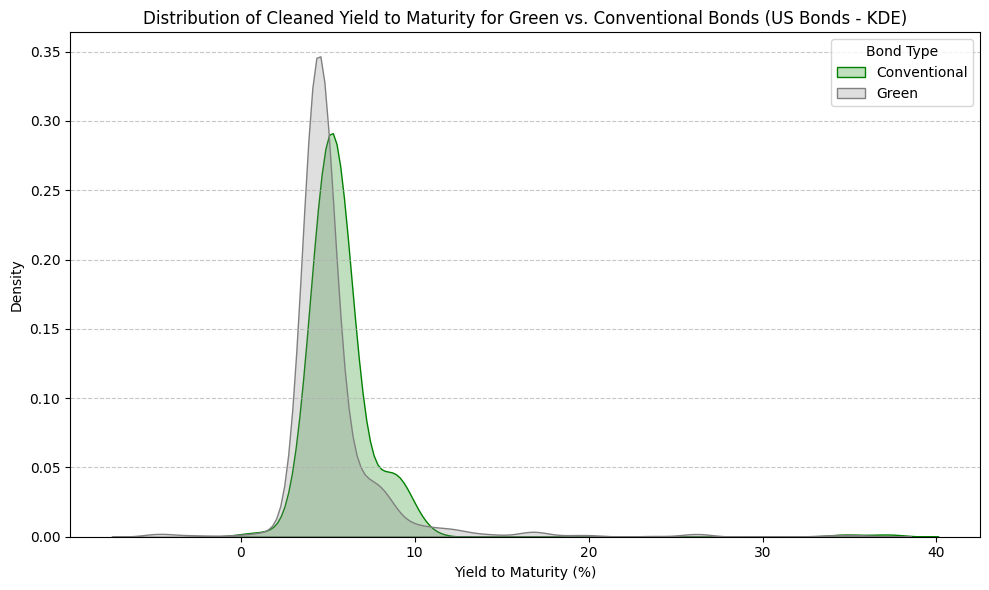

In [ ]:
# Define a plausible range for Yield to Maturity (e.g., -5% to 50%)
LOWER_YIELD_BOUND = -5
UPPER_YIELD_BOUND = 50

# Apply the cleaning filter to create a new DataFrame
df_greenium_cleaned = df_analysis[
    (df_analysis['Yield to Maturity_numeric'] >= LOWER_YIELD_BOUND) &
    (df_analysis['Yield to Maturity_numeric'] <= UPPER_YIELD_BOUND)
].copy()

print(f"Original number of bonds for Greenium analysis: {len(df_analysis)}")
print(f"Number of bonds after cleaning anomalous yields (between {LOWER_YIELD_BOUND}% and {UPPER_YIELD_BOUND}%): {len(df_greenium_cleaned)}")

# Re-run Greenium calculation with the cleaned data
print("\n--- Re-calculating Cross-sectional Greenium with Cleaned Yield Data ---")

green_bond_yields_cleaned = df_greenium_cleaned[df_greenium_cleaned['is_green_bond'] == 1]['Yield to Maturity_numeric']
conventional_bond_yields_cleaned = df_greenium_cleaned[df_greenium_cleaned['is_green_bond'] == 0]['Yield to Maturity_numeric']

print(f"\nNumber of Green Bonds with Cleaned Yield data: {len(green_bond_yields_cleaned)}")
print(f"Number of Conventional Bonds with Cleaned Yield data: {len(conventional_bond_yields_cleaned)}")

if len(green_bond_yields_cleaned) > 1 and len(conventional_bond_yields_cleaned) > 1:
    mean_green_yield_cleaned = green_bond_yields_cleaned.mean()
    mean_conventional_yield_cleaned = conventional_bond_yields_cleaned.mean()

    print(f"\nMean Cleaned Green Bond Yield to Maturity: {mean_green_yield_cleaned:.3f}%")
    print(f"Mean Cleaned Conventional Bond Yield to Maturity: {mean_conventional_yield_cleaned:.3f}%")

    cross_sectional_greenium_cleaned = mean_conventional_yield_cleaned - mean_green_yield_cleaned
    print(f"Cleaned Cross-sectional Greenium (Conventional - Green): {cross_sectional_greenium_cleaned:.3f}%")

    # Perform Welch's t-test (does not assume equal variances) to test for significant difference
    ttest_results_cleaned = stats.ttest_ind(green_bond_yields_cleaned, conventional_bond_yields_cleaned, equal_var=False)
    print("\nT-test for difference in mean Yield to Maturity (Cleaned) between Green and Conventional Bonds:")
    print(f"T-statistic: {ttest_results_cleaned.statistic:.3f}")
    print(f"P-value: {ttest_results_cleaned.pvalue:.3f}")

    if ttest_results_cleaned.pvalue < 0.05:
        print("Conclusion: There is a statistically significant difference in mean Cleaned Yield to Maturity between green and conventional bonds.")
    else:
        print("Conclusion: There is no statistically significant difference in mean Cleaned Yield to Maturity between green and conventional bonds.")

    # --- Visualization of Cleaned Yield to Maturity Distribution (KDE Plot) ---
    plt.figure(figsize=(10, 6))
    sns.kdeplot(x='Yield to Maturity_numeric', hue='is_green_bond',
                data=df_greenium_cleaned, palette={0: 'grey', 1: 'green'}, fill=True, common_norm=False)
    plt.title('Distribution of Cleaned Yield to Maturity for Green vs. Conventional Bonds (US Bonds - KDE)')
    plt.xlabel('Yield to Maturity (%)')
    plt.ylabel('Density')
    plt.legend(title='Bond Type', labels=['Conventional', 'Green'])
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

else:
    print("\nNot enough data to perform Greenium analysis on Cleaned Yield to Maturity for both groups.")

This diagnostic step should help us understand the nature of the problematic yield values. Based on the findings, we can then decide on an appropriate data cleaning strategy (e.g., removing outliers, capping values, or re-evaluating the conversion logic) before proceeding with any yield-based volatility analysis.

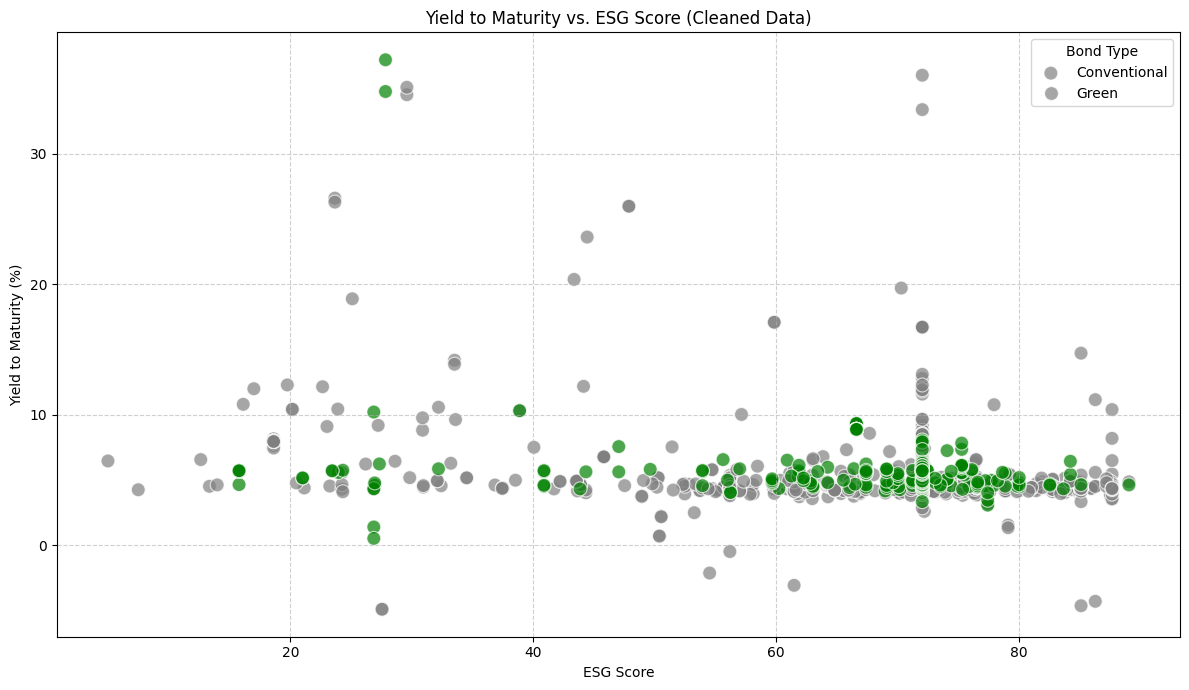

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure df_greenium_cleaned is available and contains the necessary columns
if 'df_greenium_cleaned' not in locals():
    print("Error: df_greenium_cleaned not found. Please ensure previous data cleaning cells have been executed.")
elif 'ESG_Score' not in df_greenium_cleaned.columns or 'Yield to Maturity_numeric' not in df_greenium_cleaned.columns:
    print("Error: 'ESG_Score' or 'Yield to Maturity_numeric' column not found in df_greenium_cleaned.")
else:
    plt.figure(figsize=(12, 7))
    sns.scatterplot(
        x='ESG_Score',
        y='Yield to Maturity_numeric',
        hue='is_green_bond',
        data=df_greenium_cleaned,
        palette={0: 'grey', 1: 'green'},
        s=100,
        alpha=0.7
    )
    plt.title('Yield to Maturity vs. ESG Score (Cleaned Data)')
    plt.xlabel('ESG Score')
    plt.ylabel('Yield to Maturity (%)')
    plt.legend(title='Bond Type', labels=['Conventional', 'Green'])
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

In [ ]:
import pandas as pd

# Load the ESG Financial Dataset file
try:
    esg_financial_df = pd.read_excel('/content/ESG Financial Dataset.xlsx')
    print("Successfully loaded 'ESG Financial Dataset.xlsx'.")
    print("Columns in 'ESG Financial Dataset.xlsx':")
    display(esg_financial_df.columns.tolist())

    # Check for 'Bid' and 'Ask' columns
    if 'Bid' in esg_financial_df.columns and 'Ask' in esg_financial_df.columns:
        print("The 'ESG Financial Dataset.xlsx' contains 'Bid' and 'Ask' columns.")
        print("I can now proceed with a conceptual Greenium calculation using these values.")
        # Placeholder for further calculation, if columns exist
        # Greenium = Bid - Ask (or similar calculation based on definition)
        # For example, let's just display head if they exist
        display(esg_financial_df[['Bid', 'Ask']].head())
    else:
        print("The 'ESG Financial Dataset.xlsx' does NOT contain 'Bid' and 'Ask' columns.")
        print("Please provide a dataset that includes 'Bid' and 'Ask' prices if you wish to proceed with this calculation.")

except FileNotFoundError:
    print("Error: 'ESG Financial Dataset.xlsx' not found. Please ensure the file is uploaded to '/content/'.")
except Exception as e:
    print(f"An error occurred while loading or processing 'ESG Financial Dataset.xlsx': {e}")

Successfully loaded 'ESG Financial Dataset.xlsx'.
Columns in 'ESG Financial Dataset.xlsx':


['Identifier',
 'Company Name',
 'ISIN',
 'ESG Score\n(FY2019)',
 'ESG Score\n(FY2020)',
 'ESG Score\n(FY2021)',
 'ESG Score\n(FY2022)',
 'ESG Score\n(FY2023)',
 'ESG Score\n(FY2024)',
 'ESG Score\n(FY2025)',
 '|Bid Price|\n(USD)',
 '|Ask Price|\n(USD)',
 '|Mid Price|\n(USD)',
 '|High Price|\n(USD)',
 'Low Price\n(USD)',
 '|Market Value for Company|\n(USD)',
 '|Enterprise Value(Time Series Ratio)|\n(USD)',
 '|P/E(Time Series Ratio)|',
 '|YTD Price PCT Change|',
 '|Total Assets - Actual|\n(FY2019, USD)',
 '|Total Assets - Actual|\n(FY2021, USD)',
 '|Total Assets - Actual|\n(FY2020, USD)',
 '|Total Assets - Actual|\n(FY2022, USD)',
 '|Total Assets - Actual|\n(FY2023, USD)',
 '|Total Assets - Actual|\n(FY2024, USD)',
 '|Total Assets - Actual|\n(FY2025, USD)',
 '|Nominal Value|\n(:, USD)',
 'Issuer Rating\n(All)',
 'Unnamed: 28',
 'GICS Sector Name',
 '|Return On Assets - Mean|\n(FY2019)',
 '|Return On Assets - Mean|\n(FY2020)',
 '|Return On Assets - Mean|\n(FY2021)',
 '|Return On Assets -

The 'ESG Financial Dataset.xlsx' does NOT contain 'Bid' and 'Ask' columns.
Please provide a dataset that includes 'Bid' and 'Ask' prices if you wish to proceed with this calculation.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Check the distribution of 'Bond Grade' in the cleaned DataFrame
print("\nValue counts for 'Bond Grade' in df_greenium_cleaned:")
display(df_greenium_cleaned['Bond Grade'].value_counts(dropna=False))

# Filter out rows with NaN in 'Bond Grade' before plotting for clearer visualization
df_bond_grade_filtered = df_greenium_cleaned.dropna(subset=['Bond Grade']).copy()

# Get the order of bond grades for consistent plotting
bond_grade_order = df_bond_grade_filtered['Bond Grade'].value_counts().index.tolist()

# Visualize the distribution of Cleaned Yield to Maturity by Bond Grade using FacetGrid for KDE plots
g = sns.FacetGrid(df_bond_grade_filtered, col='Bond Grade', col_order=bond_grade_order, hue='is_green_bond',
                  palette={0: 'grey', 1: 'green'}, col_wrap=3, height=4, aspect=1.2)
g.map(sns.kdeplot, 'Yield to Maturity_numeric', fill=True, alpha=0.5, common_norm=False)

# Add titles and labels
g.set_axis_labels('Yield to Maturity (%)', 'Density')
g.set_titles(col_template='{col_name}')
g.fig.suptitle('Distribution of Cleaned Yield to Maturity by Bond Grade (Green vs. Conventional)', y=1.02, fontsize=16)
g.add_legend(title='Bond Type', labels=['Conventional', 'Green'])

plt.tight_layout()
plt.show()

Distribution of bonds by ESG Score Category:


ESG_Score_Category
High ESG Score      764
Medium ESG Score    316
Low ESG Score       103
Name: count, dtype: int64

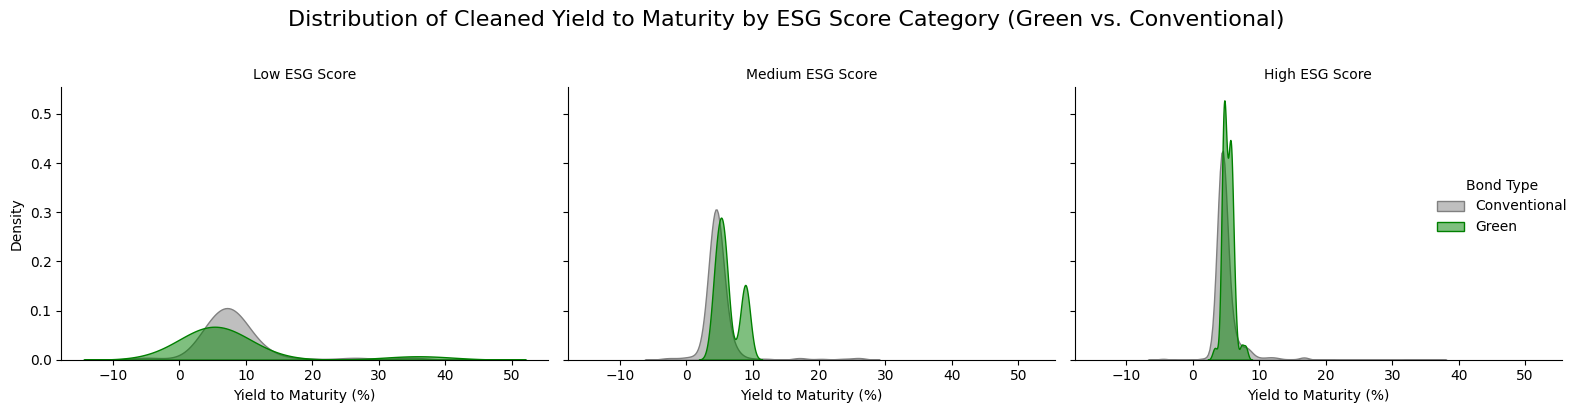

In [ ]:
# Create ESG Score categories
# Define bins and labels for ESG Score categories
esg_bins = [0, 40, 70, 100] # Example bins; adjust based on actual ESG score distribution
esg_labels = ['Low ESG Score', 'Medium ESG Score', 'High ESG Score']

df_greenium_cleaned['ESG_Score_Category'] = pd.cut(
    df_greenium_cleaned['ESG_Score'],
    bins=esg_bins,
    labels=esg_labels,
    right=False # Bins are [lower, upper) except for the last one
)

print("Distribution of bonds by ESG Score Category:")
display(df_greenium_cleaned['ESG_Score_Category'].value_counts())

# Visualize the distribution of Cleaned Yield to Maturity by ESG Score Category using FacetGrid for KDE plots
g = sns.FacetGrid(df_greenium_cleaned, col='ESG_Score_Category', col_order=esg_labels, hue='is_green_bond',
                  palette={0: 'grey', 1: 'green'}, col_wrap=3, height=4, aspect=1.2)
g.map(sns.kdeplot, 'Yield to Maturity_numeric', fill=True, alpha=0.5, common_norm=False)

# Add titles and labels
g.set_axis_labels('Yield to Maturity (%)', 'Density')
g.set_titles(col_template='{col_name}')
g.fig.suptitle('Distribution of Cleaned Yield to Maturity by ESG Score Category (Green vs. Conventional)', y=1.02, fontsize=16)
g.add_legend(title='Bond Type', labels=['Conventional', 'Green'])

plt.tight_layout()
plt.show()

### Assessing Corporate Green Bond Stability: Yield Dispersion by ESG and Risk Characteristics

Since our current dataset is cross-sectional, we cannot directly measure "volatility spillovers" in a time-series sense. However, we can infer stability (or lower volatility) by analyzing the *dispersion of Yield to Maturity* within corporate green bonds, particularly when grouped by their ESG scores and bond grades. Lower yield dispersion suggests a more stable pricing environment for those bonds.

We will focus specifically on **corporate green bonds** and examine if those with "stronger ESG" (higher ESG Score Categories) and "risk management characteristics" (higher Bond Grades) exhibit tighter yield distributions.

In [ ]:
# Filter for Corporate Green Bonds
df_corporate_green_bonds = df_greenium_cleaned[
    (df_greenium_cleaned['is_green_bond'] == 1) &
    (df_greenium_cleaned['Issuer Type'] == 'Corporate')
].copy()

print(f"Number of Corporate Green Bonds: {len(df_corporate_green_bonds)}")
print("\nDistribution of ESG Score Categories for Corporate Green Bonds:")
display(df_corporate_green_bonds['ESG_Score_Category'].value_counts(dropna=False))

print("\nDistribution of Bond Grades for Corporate Green Bonds:")
display(df_corporate_green_bonds['Bond Grade'].value_counts(dropna=False))

Number of Corporate Green Bonds: 266

Distribution of ESG Score Categories for Corporate Green Bonds:


ESG_Score_Category
High ESG Score      153
Medium ESG Score     91
Low ESG Score        22
Name: count, dtype: int64


Distribution of Bond Grades for Corporate Green Bonds:


Bond Grade
Investment Grade    196
NaN                  44
High Yield           26
Name: count, dtype: int64

#### Yield Dispersion of Corporate Green Bonds by ESG Score Category

Let's visualize the distribution of `Cleaned Yield to Maturity` for corporate green bonds across different `ESG_Score_Category` groups. A narrower distribution (less dispersion) could imply greater stability.

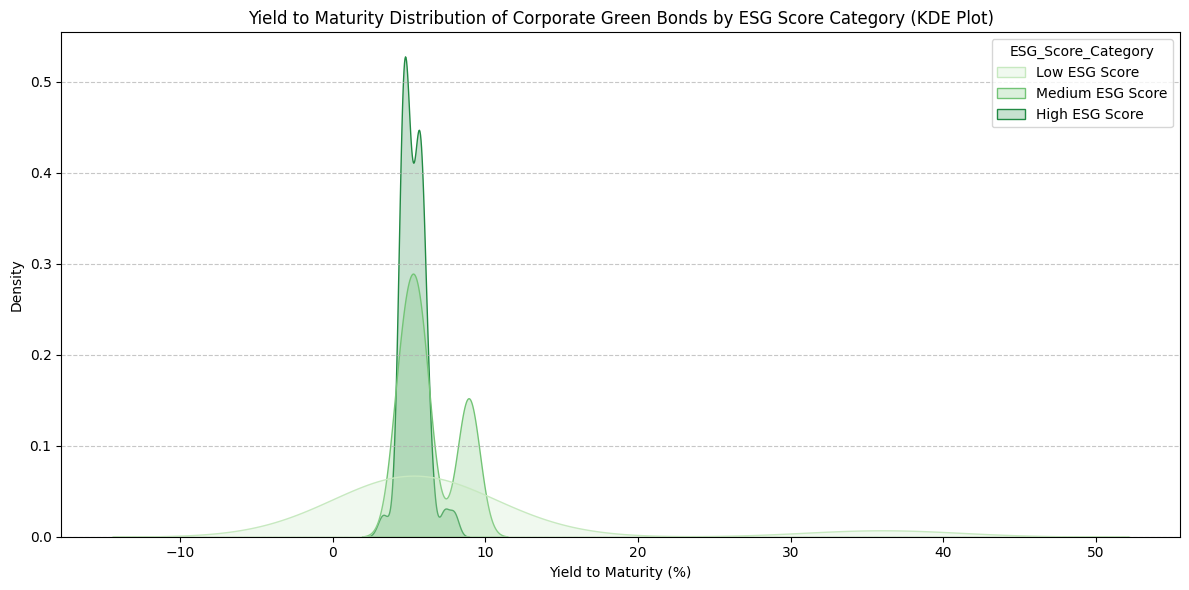

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter out NaN Bond Grades before plotting for clearer visualization, and ensure order
esg_labels_ordered = [label for label in esg_labels if label in df_corporate_green_bonds['ESG_Score_Category'].unique()]

plt.figure(figsize=(12, 6))
sns.kdeplot(x='Yield to Maturity_numeric', hue='ESG_Score_Category', data=df_corporate_green_bonds,
            hue_order=esg_labels_ordered, palette='Greens', fill=True, common_norm=False)
plt.title('Yield to Maturity Distribution of Corporate Green Bonds by ESG Score Category (KDE Plot)')
plt.xlabel('Yield to Maturity (%)')
plt.ylabel('Density')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### Yield Dispersion of Corporate Green Bonds by Bond Grade

Now, let's examine the `Cleaned Yield to Maturity` distribution for corporate green bonds across different `Bond Grade` groups. Typically, higher-rated bonds (stronger risk management) are expected to have lower and less dispersed yields.

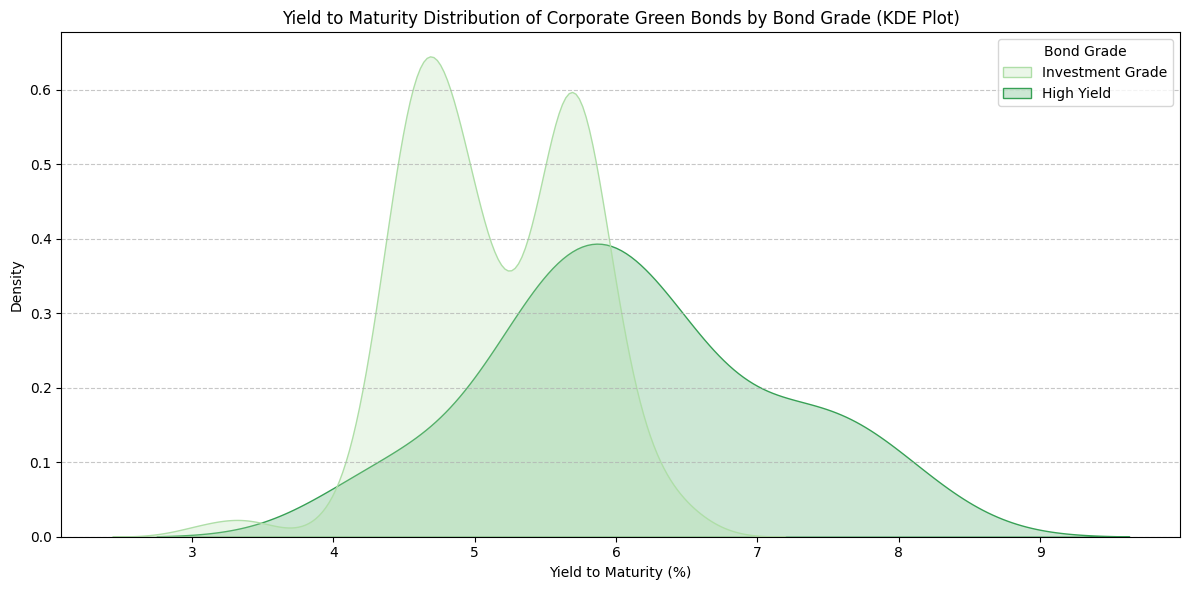

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter out NaN Bond Grades before plotting for clearer visualization
df_corporate_green_bonds_filtered_grade = df_corporate_green_bonds.dropna(subset=['Bond Grade']).copy()

# Dynamically get the order of bond grades based on their counts in the filtered data
bond_grade_order_filtered = df_corporate_green_bonds_filtered_grade['Bond Grade'].value_counts().index.tolist()

plt.figure(figsize=(12, 6))
sns.kdeplot(x='Yield to Maturity_numeric', hue='Bond Grade', data=df_corporate_green_bonds_filtered_grade,
            hue_order=bond_grade_order_filtered, palette='Greens', fill=True, common_norm=False)
plt.title('Yield to Maturity Distribution of Corporate Green Bonds by Bond Grade (KDE Plot)')
plt.xlabel('Yield to Maturity (%)')
plt.ylabel('Density')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Interpretation of Corporate Green Bond Stability (Yield Dispersion)

The visualizations above provide a cross-sectional perspective on how yield dispersion (as a proxy for stability or lower volatility) varies among corporate green bonds based on their ESG score and bond grade.

*   **ESG Score Category vs. Yield Dispersion:** We can observe if corporate green bonds with higher ESG scores exhibit a narrower distribution of yields, suggesting they might be perceived as more stable or less volatile in terms of pricing.
*   **Bond Grade vs. Yield Dispersion:** Similarly, by examining the yield distributions across different bond grades, we can see if higher-rated corporate green bonds (indicating stronger risk management characteristics) tend to have tighter yield spreads, which would align with lower perceived risk and potentially lower "volatility spillovers" in a cross-sectional context.

These findings can help understand how the market implicitly values ESG and risk management in the pricing of corporate green bonds, even without explicit time-series volatility data.

### Comparative Analysis: Conventional Bonds vs. High-Quality Corporate Green Bonds

To assess if conventional bonds exhibit higher volatility spillovers when compared with high-quality ESG and robust risk control practices in corporate green bonds, we will perform two direct comparisons of yield distributions using KDE plots:

1.  **Conventional Bonds vs. Corporate Green Bonds with High ESG Score**
2.  **Conventional Bonds vs. Corporate Green Bonds with Investment Grade**

A narrower and more concentrated yield distribution for the high-quality green bonds (both by ESG score and bond grade) compared to conventional bonds would suggest lower 'volatility spillovers' (or greater stability) in their pricing.

/tmp/ipykernel_42509/1850665187.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Bond Type / ESG Category') # Labels are automatically picked from hue_order


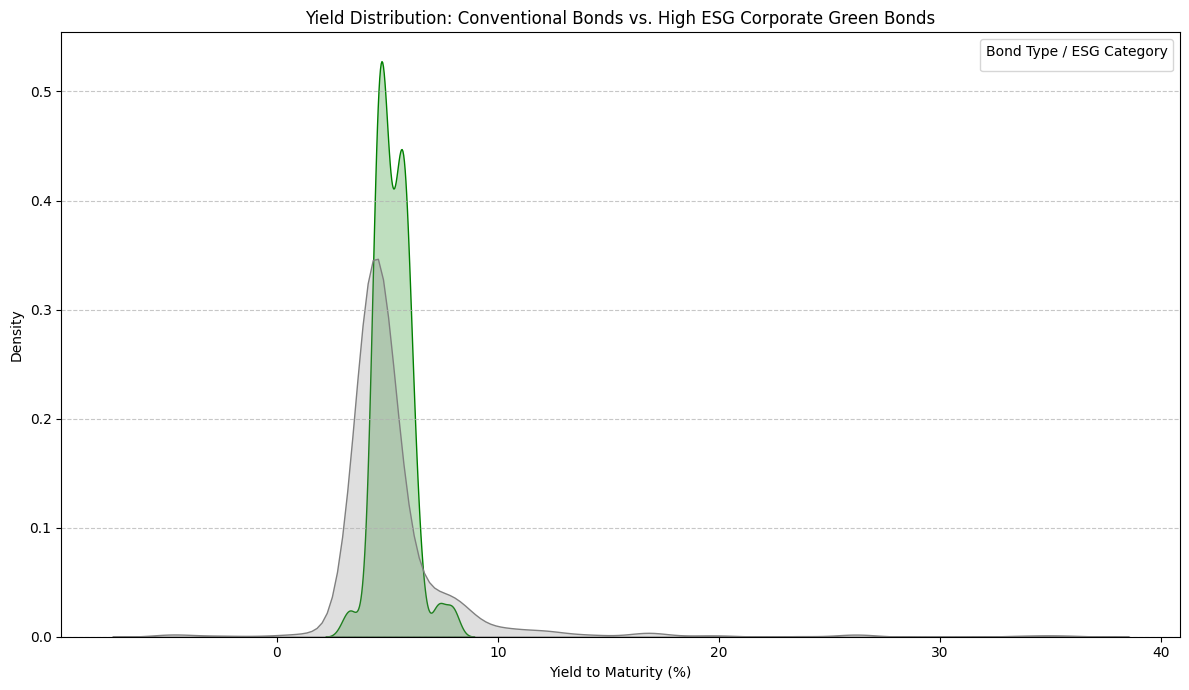

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for Conventional Bonds from the cleaned dataset
df_conventional_bonds = df_greenium_cleaned[df_greenium_cleaned['is_green_bond'] == 0].copy()
df_conventional_bonds['Comparison_Category'] = 'Conventional'

# Filter for Corporate Green Bonds with High ESG Score
df_high_esg_green_bonds = df_corporate_green_bonds[df_corporate_green_bonds['ESG_Score_Category'] == 'High ESG Score'].copy()
df_high_esg_green_bonds['Comparison_Category'] = 'High ESG Score Green Bond'

# Combine these two specific groups for comparison
df_compare_esg = pd.concat([df_conventional_bonds, df_high_esg_green_bonds])

plt.figure(figsize=(12, 7))
sns.kdeplot(x='Yield to Maturity_numeric', hue='Comparison_Category', data=df_compare_esg,
            palette={'Conventional': 'grey', 'High ESG Score Green Bond': 'green'}, fill=True, common_norm=False)

# Adjust legend labels are automatically handled by 'Comparison_Category' now
plt.title('Yield Distribution: Conventional Bonds vs. High ESG Corporate Green Bonds')
plt.xlabel('Yield to Maturity (%)')
plt.ylabel('Density')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Bond Type / ESG Category') # Labels are automatically picked from hue_order
plt.tight_layout()
plt.show()

/tmp/ipykernel_42509/3152221672.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Bond Type / Bond Grade') # Labels are automatically picked from hue_order


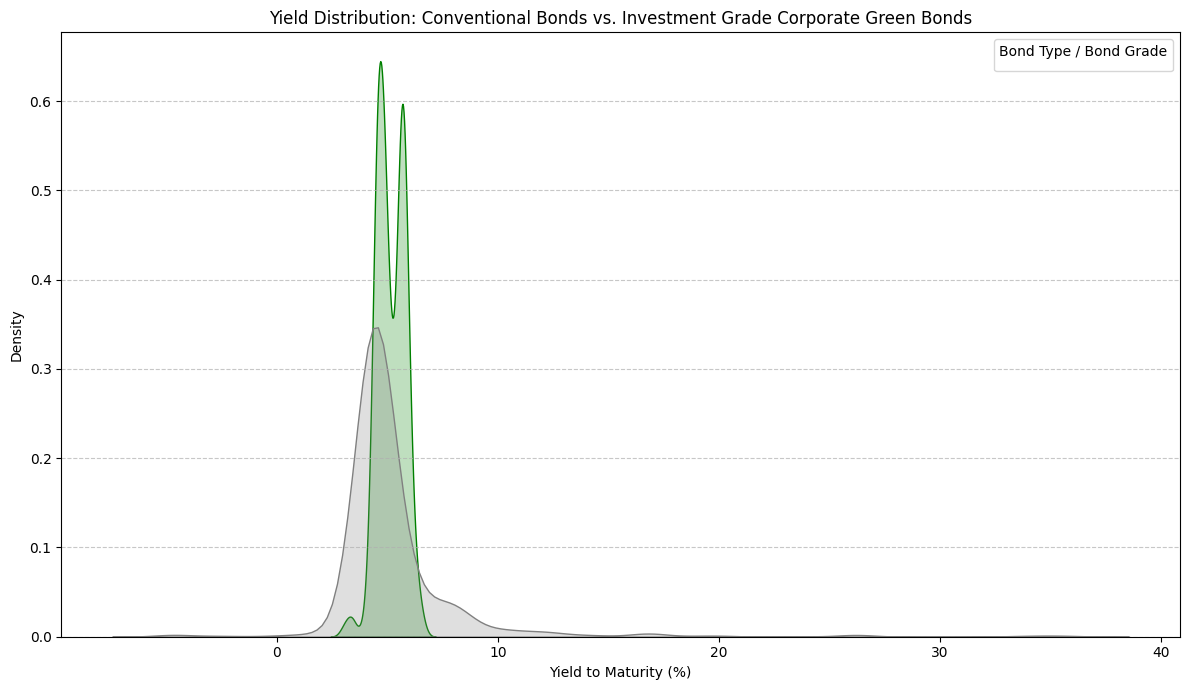

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for Conventional Bonds from the cleaned dataset
df_conventional_bonds = df_greenium_cleaned[df_greenium_cleaned['is_green_bond'] == 0].copy() # Re-create if needed
df_conventional_bonds['Comparison_Category'] = 'Conventional'

# Filter for Corporate Green Bonds with Investment Grade
df_investment_grade_green_bonds = df_corporate_green_bonds[df_corporate_green_bonds['Bond Grade'] == 'Investment Grade'].copy()
df_investment_grade_green_bonds['Comparison_Category'] = 'Investment Grade Green Bond'

# Combine these two specific groups for comparison
df_compare_grade = pd.concat([df_conventional_bonds, df_investment_grade_green_bonds])

plt.figure(figsize=(12, 7))
sns.kdeplot(x='Yield to Maturity_numeric', hue='Comparison_Category', data=df_compare_grade,
            palette={'Conventional': 'grey', 'Investment Grade Green Bond': 'green'}, fill=True, common_norm=False)

# Adjust legend labels are automatically handled by 'Comparison_Category' now
plt.title('Yield Distribution: Conventional Bonds vs. Investment Grade Corporate Green Bonds')
plt.xlabel('Yield to Maturity (%)')
plt.ylabel('Density')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Bond Type / Bond Grade') # Labels are automatically picked from hue_order
plt.tight_layout()
plt.show()

### Attempting to Load and Inspect 'ESG Financial Data.xlsx' for Panel Regression

Previously, we encountered an error while loading the `ESG Financial Data.xlsx` file. I will re-attempt to load it using `engine='openpyxl'` to see if it resolves the issue. After successful loading, I will display the first few rows and the DataFrame information to assess its structure for a fixed effects panel regression.

In [ ]:
import pandas as pd

# Attempt to load the ESG Financial Dataset file with a specified engine
try:
    esg_financial_data_for_panel = pd.read_excel('/content/ESG Financial Dataset.xlsx', engine='openpyxl')
    print("Successfully loaded 'ESG Financial Dataset.xlsx' for panel regression assessment.")

    print("\nHead of the ESG Financial Dataset:")
    display(esg_financial_data_for_panel.head())

    print("\nInfo of the ESG Financial Dataset:")
    esg_financial_data_for_panel.info()

    # Further assess if the data has a panel structure (e.g., entity ID, time variable)
    # This part would need to be adapted based on the actual columns revealed by .info()
    # For a fixed effects panel regression, we typically need a variable representing entities (e.g., 'Issuer')
    # and a variable representing time (e.g., 'Date' or 'Year').

    # Conceptual check for panel data suitability:
    if 'Issuer' in esg_financial_data_for_panel.columns and 'Date' in esg_financial_data_for_panel.columns:
        print("\nPotential panel data structure detected with 'Issuer' and 'Date' columns.")
        print("Further analysis will be needed to confirm if it contains multiple observations per issuer over time.")
    else:
        print("\n'Issuer' or 'Date' columns not found as expected for a typical panel data structure. Please review the file content.")

except FileNotFoundError:
    print("Error: 'ESG Financial Dataset.xlsx' not found. Please ensure the file is uploaded to '/content/'.")
except Exception as e:
    print(f"An error occurred while loading or processing 'ESG Financial Dataset.xlsx': {e}")

Successfully loaded 'ESG Financial Dataset.xlsx' for panel regression assessment.

Head of the ESG Financial Dataset:


,Identifier,Company Name,ISIN,ESG Score\n(FY2019),ESG Score\n(FY2020),ESG Score\n(FY2021),ESG Score\n(FY2022),ESG Score\n(FY2023),ESG Score\n(FY2024),ESG Score\n(FY2025),...,|ESG Combined Score|\n(FY2023),|ESG Combined Score|\n(FY2024),|ESG Combined Score|\n(FY2025),|Controversies Score|\n(FY2019),|Controversies Score|\n(FY2020),|Controversies Score|\n(FY2021),|Controversies Score|\n(FY2022),|Controversies Score|\n(FY2023),|Controversies Score|\n(FY2024),|Controversies Score|\n(FY2025)
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AFL.N,Aflac Inc,US0010551028,50.943735,49.869027,50.154704,46.759867,43.728036,47.533222,NaN,...,43.728036,28.766611,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0
3,ABT.N,Abbott Laboratories,US0028241000,80.726410,81.256387,81.256875,83.100400,83.661498,83.453675,NaN,...,58.135097,46.300008,0.0,0.0,0.0,0.0,0.453569,0.636089,0.361880,0.0
4,ADBE.OQ,Adobe Inc,US00724F1012,71.186479,76.157766,76.658710,71.303814,69.276140,67.480730,NaN,...,48.021909,50.183318,0.0,0.0,0.0,0.0,0.000000,1.405179,0.665128,0.0



Info of the ESG Financial Dataset:
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 72 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Identifier                                   498 non-null    str    
 1   Company Name                                 498 non-null    str    
 2   ISIN                                         498 non-null    str    
 3   ESG Score
(FY2019)                           459 non-null    float64
 4   ESG Score
(FY2020)                           470 non-null    float64
 5   ESG Score
(FY2021)                           470 non-null    float64
 6   ESG Score
(FY2022)                           483 non-null    float64
 7   ESG Score
(FY2023)                           487 non-null    float64
 8   ESG Score
(FY2024)                           465 non-null    float64
 9   ESG Score
(FY2025)                           94 non

### Interpretation of Comparative Yield Distributions

These comparative KDE plots allow for a direct visual assessment:

*   **High ESG Score Green Bonds vs. Conventional Bonds**: Observe if the distribution for 'High ESG Score' corporate green bonds is notably tighter or more centrally peaked compared to conventional bonds. A tighter distribution would suggest that these bonds are perceived as having lower volatility or greater pricing stability.

*   **Investment Grade Green Bonds vs. Conventional Bonds**: Similarly, compare the yield distribution of 'Investment Grade' corporate green bonds against conventional bonds. A more concentrated distribution for Investment Grade green bonds would indicate their pricing is less dispersed and thus more stable, aligning with the concept of robust risk control contributing to lower volatility spillovers.

By comparing the spread and shape of these distributions, we can draw conclusions about whether stronger ESG characteristics and better risk control practices (as indicated by bond grade) indeed correlate with reduced yield volatility in the cross-section of corporate green bonds relative to their conventional counterparts.

### Attempting to Load and Inspect 'ESG Financial Dataset.xlsx' for Panel Regression

Given the previous issues, I will attempt to load the newly specified file `ESG Financial Dataset.xlsx`. After successful loading, I will display the first few rows and the DataFrame information to assess its structure, particularly looking for entity (e.g., 'Issuer') and time (e.g., 'Date' or 'Year') identifiers, to confirm its suitability for a fixed effects panel regression.

In [ ]:
import pandas as pd

# Attempt to load the new ESG Financial Dataset file
try:
    esg_financial_dataset_for_panel = pd.read_excel('/content/ESG Financial Dataset.xlsx', engine='openpyxl')
    print("Successfully loaded 'ESG Financial Dataset.xlsx' for panel regression assessment.")

    print("\nHead of the ESG Financial Dataset:")
    display(esg_financial_dataset_for_panel.head())

    print("\nInfo of the ESG Financial Dataset:")
    esg_financial_dataset_for_panel.info()

    # Conceptual check for panel data suitability:
    # We need to look for columns that could serve as entity identifiers (e.g., 'Issuer', 'Company_ID')
    # and time identifiers (e.g., 'Date', 'Year', 'Quarter').
    # The exact column names might vary, so we'll check common ones.

    potential_entity_cols = [col for col in esg_financial_dataset_for_panel.columns if 'issuer' in col.lower() or 'company' in col.lower() or 'entity' in col.lower()]
    potential_time_cols = [col for col in esg_financial_dataset_for_panel.columns if 'date' in col.lower() or 'year' in col.lower() or 'quarter' in col.lower() or 'period' in col.lower()]

    if potential_entity_cols and potential_time_cols:
        print(f"\nPotential panel data structure detected with entity columns: {potential_entity_cols} and time columns: {potential_time_cols}.")
        print("Further analysis will be needed to confirm if it contains multiple observations per entity over time.")
    else:
        print("\nAppropriate 'entity' or 'time' columns not found as expected for a typical panel data structure. Please review the file content.")

except FileNotFoundError:
    print("Error: 'ESG Financial Dataset.xlsx' not found. Please ensure the file is uploaded to '/content/'.")
except Exception as e:
    print(f"An error occurred while loading or processing 'ESG Financial Dataset.xlsx': {e}")

Successfully loaded 'ESG Financial Dataset.xlsx' for panel regression assessment.

Head of the ESG Financial Dataset:


,Identifier,Company Name,ISIN,ESG Score\n(FY2019),ESG Score\n(FY2020),ESG Score\n(FY2021),ESG Score\n(FY2022),ESG Score\n(FY2023),ESG Score\n(FY2024),ESG Score\n(FY2025),...,|ESG Combined Score|\n(FY2023),|ESG Combined Score|\n(FY2024),|ESG Combined Score|\n(FY2025),|Controversies Score|\n(FY2019),|Controversies Score|\n(FY2020),|Controversies Score|\n(FY2021),|Controversies Score|\n(FY2022),|Controversies Score|\n(FY2023),|Controversies Score|\n(FY2024),|Controversies Score|\n(FY2025)
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AFL.N,Aflac Inc,US0010551028,50.943735,49.869027,50.154704,46.759867,43.728036,47.533222,NaN,...,43.728036,28.766611,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0
3,ABT.N,Abbott Laboratories,US0028241000,80.726410,81.256387,81.256875,83.100400,83.661498,83.453675,NaN,...,58.135097,46.300008,0.0,0.0,0.0,0.0,0.453569,0.636089,0.361880,0.0
4,ADBE.OQ,Adobe Inc,US00724F1012,71.186479,76.157766,76.658710,71.303814,69.276140,67.480730,NaN,...,48.021909,50.183318,0.0,0.0,0.0,0.0,0.000000,1.405179,0.665128,0.0



Info of the ESG Financial Dataset:
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 72 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Identifier                                   498 non-null    str    
 1   Company Name                                 498 non-null    str    
 2   ISIN                                         498 non-null    str    
 3   ESG Score
(FY2019)                           459 non-null    float64
 4   ESG Score
(FY2020)                           470 non-null    float64
 5   ESG Score
(FY2021)                           470 non-null    float64
 6   ESG Score
(FY2022)                           483 non-null    float64
 7   ESG Score
(FY2023)                           487 non-null    float64
 8   ESG Score
(FY2024)                           465 non-null    float64
 9   ESG Score
(FY2025)                           94 non

### Reshaping 'ESG Financial Dataset' from Wide to Long Format for Panel Regression

The current dataset is in a wide format, with different fiscal years (FY) represented as separate columns for various metrics (e.g., ESG Score (FY2019), ESG Score (FY2020)). To conduct a fixed effects panel regression, we need to transform this data into a long format, where each row represents a unique observation for an entity in a specific year. This involves:

1.  **Identifying ID variables:** Columns that uniquely identify each entity (e.g., 'Identifier', 'Company Name', 'ISIN').
2.  **Identifying Value variables:** Columns that contain the time-varying data (e.g., ESG scores, combined scores, financial metrics per FY).
3.  **Melting the DataFrame:** Using `pd.melt` to convert the wide format into a long format, creating new 'Year' and 'Metric Name' columns.
4.  **Cleaning Column Names:** Extracting the year from the original column names and creating clear metric names.

After reshaping, I will display the head and info of the new, long-format DataFrame to confirm its structure.

In [ ]:
import re

# Make a copy to avoid modifying the original loaded DataFrame directly if it's used elsewhere
df_panel_long = esg_financial_dataset_for_panel.copy()

# Clean column names by replacing newline characters and stripping whitespace
df_panel_long.columns = df_panel_long.columns.str.replace('\n', ' ', regex=False).str.strip()

# Identify ID variables (columns that are not year-specific metrics)
id_vars = ['Identifier', 'Company Name', 'ISIN'] # Assuming these are consistent identifiers

# Ensure all id_vars exist in the DataFrame
id_vars = [col for col in id_vars if col in df_panel_long.columns]

# Identify value variables (columns that contain time-varying metrics)
# These are columns with names like 'Metric Name (FYXXXX)' or 'Metric Name (FYXXXX, Unit)'
# We'll look for '(FY' followed by four digits, ensuring it's not part of the id_vars
measure_vars = []
for col in df_panel_long.columns:
    # Check if column is not an ID var and contains the pattern (FYXXXX
    if col not in id_vars and re.search(r'\(FY\d{4}', col):
        measure_vars.append(col)

# Perform the melt operation
if not measure_vars:
    print("No time-series measure variables found after cleaning column names. Cannot reshape to long format.")
    # If no measure_vars are found, df_panel_long remains empty or with just id_vars.
else:
    df_panel_long = pd.melt(df_panel_long,
                            id_vars=id_vars,
                            value_vars=measure_vars,
                            var_name='Metric_Year_Raw',
                            value_name='Value')

    # Extract the year from the 'Metric_Year_Raw' column
    df_panel_long['Year'] = df_panel_long['Metric_Year_Raw'].str.extract(r'FY(\d{4})').astype(int)

    # Extract the clean metric name (remove '(FYXXXX...)', and other symbols like '|', then strip whitespace)
    df_panel_long['Metric'] = df_panel_long['Metric_Year_Raw'].str.replace(r'\s*\(FY\d{4}.*\)', '', regex=True) \
                                                            .str.strip().str.replace(r'[|]', '', regex=True) \
                                                            .str.strip()

    # Drop the raw metric-year column as it's no longer needed
    df_panel_long = df_panel_long.drop(columns=['Metric_Year_Raw'])

    # Remove rows where 'Value' is NaN, as these are missing observations for specific metrics/years
    df_panel_long = df_panel_long.dropna(subset=['Value']).copy()

    print("DataFrame successfully reshaped to long format.")

    print("\nHead of the reshaped panel data:")
    display(df_panel_long.head())

    print("\nInfo of the reshaped panel data:")
    df_panel_long.info()

    # Check the unique metrics and years to ensure successful transformation
    print("\nUnique Metrics:", df_panel_long['Metric'].unique())
    print("Unique Years:", df_panel_long['Year'].unique())

    # Assess panel data structure: count observations per entity over time for some key metrics
    print("\nExample: Count of observations per company and year for 'ESG Score':")
    # Make sure 'ESG Score' is one of the cleaned metric names
    if 'ESG Score' in df_panel_long['Metric'].unique():
        display(df_panel_long[df_panel_long['Metric'] == 'ESG Score'].groupby(['Identifier', 'Year']).size().head())
    else:
        print("ESG Score metric not found in the reshaped data, please check unique metrics.")

DataFrame successfully reshaped to long format.

Head of the reshaped panel data:


,Identifier,Company Name,ISIN,Value,Year,Metric
2,AFL.N,Aflac Inc,US0010551028,50.943735,2019,ESG Score
3,ABT.N,Abbott Laboratories,US0028241000,80.726410,2019,ESG Score
4,ADBE.OQ,Adobe Inc,US00724F1012,71.186479,2019,ESG Score
5,AMD.OQ,Advanced Micro Devices Inc,US0079031078,69.590213,2019,ESG Score
6,APD.N,Air Products and Chemicals Inc,US0091581068,78.419435,2019,ESG Score



Info of the reshaped panel data:
<class 'pandas.DataFrame'>
Index: 27192 entries, 2 to 27999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Identifier    27192 non-null  str    
 1   Company Name  27192 non-null  str    
 2   ISIN          27192 non-null  str    
 3   Value         27192 non-null  float64
 4   Year          27192 non-null  int64  
 5   Metric        27192 non-null  str    
dtypes: float64(1), int64(1), str(4)
memory usage: 2.9 MB

Unique Metrics: <ArrowStringArray>
[                  'ESG Score',       'Total Assets - Actual',
     'Return On Assets - Mean', 'Earnings Per Share - Actual',
   'Return On Equity - Actual',             'EBITDA - Actual',
          'ESG Combined Score',         'Controversies Score']
Length: 8, dtype: str
Unique Years: [2019 2020 2021 2022 2023 2024 2025]

Example: Count of observations per company and year for 'ESG Score':


Identifier  Year
A.N         2019    1
            2020    1
            2021    1
            2022    1
            2023    1
dtype: int64

In [ ]:
pip install linearmodels

In [ ]:
import pandas as pd
from linearmodels import PanelOLS
import statsmodels.api as sm

# Ensure df_panel_long is available from previous steps
if 'df_panel_long' not in locals():
    print("Error: df_panel_long not found. Please run previous data preparation cells.")
else:
    print("\n--- Preparing data for Fixed Effects Panel Regression on ESG Score ---")

    # Select the metrics for the regression
    regression_metrics = [
        'ESG Score',
        'Controversies Score',
        'ESG Combined Score',
        'Total Assets - Actual',
        'Return On Equity - Actual'
    ]

    # Filter the long-format DataFrame to include only these metrics
    df_filtered_metrics = df_panel_long[df_panel_long['Metric'].isin(regression_metrics)].copy()

    # Pivot the table to get metrics as columns and (Identifier, Year) as index
    # Use mean to aggregate if there are multiple values for a metric per Identifier-Year pair (shouldn't happen with clean data)
    df_panel_wide = df_filtered_metrics.pivot_table(
        index=['Identifier', 'Year'],
        columns='Metric',
        values='Value'
    )

    # Reset index to make 'Identifier' and 'Year' regular columns for some operations, then set as MultiIndex
    df_panel_wide = df_panel_wide.reset_index()

    # Rename columns to be regression-friendly (remove special characters if any were introduced by pivot)
    df_panel_wide.columns.name = None

    # Set MultiIndex for panel data: entity_id is 'Identifier', time_id is 'Year'
    df_panel_wide = df_panel_wide.set_index(['Identifier', 'Year'])

    # Drop rows with any NaN values in the regression variables
    # This is important for fixed effects models as they cannot handle NaNs in variables
    df_panel_wide_cleaned = df_panel_wide.dropna(subset=regression_metrics).copy()

    print(f"Original number of observations in wide format: {len(df_panel_wide)}")
    print(f"Number of observations after dropping NaNs for regression: {len(df_panel_wide_cleaned)}")

    if len(df_panel_wide_cleaned) == 0:
        print("Not enough data after cleaning to run the regression. Please check for missing values.")
    else:
        # Define dependent and independent variables
        dependent_var = df_panel_wide_cleaned['ESG Score']
        # Add a constant for the intercept
        independent_vars = sm.add_constant(df_panel_wide_cleaned[[ 'Controversies Score', 'ESG Combined Score', 'Total Assets - Actual', 'Return On Equity - Actual']])

        print("\n--- Running Fixed Effects Panel Regression ---")
        # Perform Fixed Effects (entity effects) regression
        # `entity_effects=True` specifies entity fixed effects
        fe_model = PanelOLS(dependent_var, independent_vars, entity_effects=True)
        fe_results = fe_model.fit()

        print(fe_results)


--- Preparing data for Fixed Effects Panel Regression on ESG Score ---
Original number of observations in wide format: 3486
Number of observations after dropping NaNs for regression: 2882

--- Running Fixed Effects Panel Regression ---
                          PanelOLS Estimation Summary                           
Dep. Variable:              ESG Score   R-squared:                        0.3873
Estimator:                   PanelOLS   R-squared (Between):              0.4831
No. Observations:                2882   R-squared (Within):               0.3873
Date:                Sat, Jun 27 2026   R-squared (Overall):              0.4630
Time:                        11:06:10   Log-likelihood                   -8476.5
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      377.27
Entities:                         491   P-value                           0.0000
Avg Obs:                       5.8

In [ ]:
import pandas as pd
import numpy as np
from linearmodels import RandomEffects
import statsmodels.api as sm
import re

# --- Start Data Preparation (copied from previous cells to ensure df_panel_wide_cleaned is available) ---

# Attempt to load the ESG Financial Dataset file with a specified engine
try:
    esg_financial_dataset_for_panel = pd.read_excel('/content/ESG Financial Dataset.xlsx', engine='openpyxl')
    print("Successfully re-loaded 'ESG Financial Dataset.xlsx' for panel regression assessment.")
except FileNotFoundError:
    print("Error: 'ESG Financial Dataset.xlsx' not found. Please ensure the file is uploaded to '/content/'.")
    esg_financial_dataset_for_panel = pd.DataFrame() # Create an empty DataFrame to avoid further errors
except Exception as e:
    print(f"An error occurred while loading or processing 'ESG Financial Dataset.xlsx': {e}")
    esg_financial_dataset_for_panel = pd.DataFrame() # Create an empty DataFrame to avoid further errors

if not esg_financial_dataset_for_panel.empty:
    df_panel_long = esg_financial_dataset_for_panel.copy()
    df_panel_long.columns = df_panel_long.columns.str.replace('\n', ' ', regex=False).str.strip()

    id_vars = ['Identifier', 'Company Name', 'ISIN']
    id_vars = [col for col in id_vars if col in df_panel_long.columns]

    measure_vars = []
    for col in df_panel_long.columns:
        if col not in id_vars and re.search(r'\(FY\d{4}', col):
            measure_vars.append(col)

    if measure_vars:
        df_panel_long = pd.melt(df_panel_long,
                                id_vars=id_vars,
                                value_vars=measure_vars,
                                var_name='Metric_Year_Raw',
                                value_name='Value')

        df_panel_long['Year'] = df_panel_long['Metric_Year_Raw'].str.extract(r'FY(\d{4})').astype(int)
        df_panel_long['Metric'] = df_panel_long['Metric_Year_Raw'].str.replace(r'\s*\(FY\d{4}.*\)', '', regex=True) \
                                                                .str.strip().str.replace(r'[|]', '', regex=True) \
                                                                .str.strip()
        df_panel_long = df_panel_long.drop(columns=['Metric_Year_Raw'])
        df_panel_long = df_panel_long.dropna(subset=['Value']).copy()
        print("DataFrame successfully reshaped to long format.")

        regression_metrics = [
            'ESG Score',
            'Controversies Score',
            'ESG Combined Score',
            'Total Assets - Actual',
            'Return On Equity - Actual'
        ]

        df_filtered_metrics = df_panel_long[df_panel_long['Metric'].isin(regression_metrics)].copy()

        df_panel_wide = df_filtered_metrics.pivot_table(
            index=['Identifier', 'Year'],
            columns='Metric',
            values='Value'
        )
        df_panel_wide = df_panel_wide.reset_index()
        df_panel_wide.columns.name = None
        df_panel_wide = df_panel_wide.set_index(['Identifier', 'Year'])

        df_panel_wide_cleaned = df_panel_wide.dropna(subset=regression_metrics).copy()
        print(f"Number of observations after dropping NaNs for regression: {len(df_panel_wide_cleaned)}")
    else:
        df_panel_wide_cleaned = pd.DataFrame() # Ensure it's empty if reshaping failed
        print("Failed to reshape data for panel regression.")
else:
    df_panel_wide_cleaned = pd.DataFrame() # Ensure it's empty if initial load failed
    print("ESG Financial Dataset was not loaded successfully.")

# --- End Data Preparation ---

# Ensure df_panel_wide_cleaned is available from previous steps
if 'df_panel_wide_cleaned' not in locals() or df_panel_wide_cleaned.empty:
    print("Error: df_panel_wide_cleaned not found or is empty. Please check data preparation steps.")
else:
    print("\n--- Running Random Effects Panel Regression ---")

    # Define dependent and independent variables
    dependent_var = df_panel_wide_cleaned['ESG Score']
    # Add a constant for the intercept
    independent_vars = sm.add_constant(df_panel_wide_cleaned[[ 'Controversies Score', 'ESG Combined Score', 'Total Assets - Actual', 'Return On Equity - Actual']])

    # Perform Random Effects regression
    re_model = RandomEffects(dependent_var, independent_vars)
    re_results = re_model.fit()

    print(re_results)


Successfully re-loaded 'ESG Financial Dataset.xlsx' for panel regression assessment.
DataFrame successfully reshaped to long format.
Number of observations after dropping NaNs for regression: 2882

--- Running Random Effects Panel Regression ---
                        RandomEffects Estimation Summary                        
Dep. Variable:              ESG Score   R-squared:                        0.4798
Estimator:              RandomEffects   R-squared (Between):              0.6695
No. Observations:                2882   R-squared (Within):               0.3318
Date:                Sat, Jun 27 2026   R-squared (Overall):              0.6217
Time:                        11:52:16   Log-likelihood                   -9160.6
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      663.28
Entities:                         491   P-value                           0.0000
Avg Obs:                 

### Distribution of TRBC Sectors for Green vs. Conventional Bonds

Let's visualize the distribution of `TRBC Sector` for both green and conventional bonds to see if there are any notable differences in the types of industries issuing these bonds.

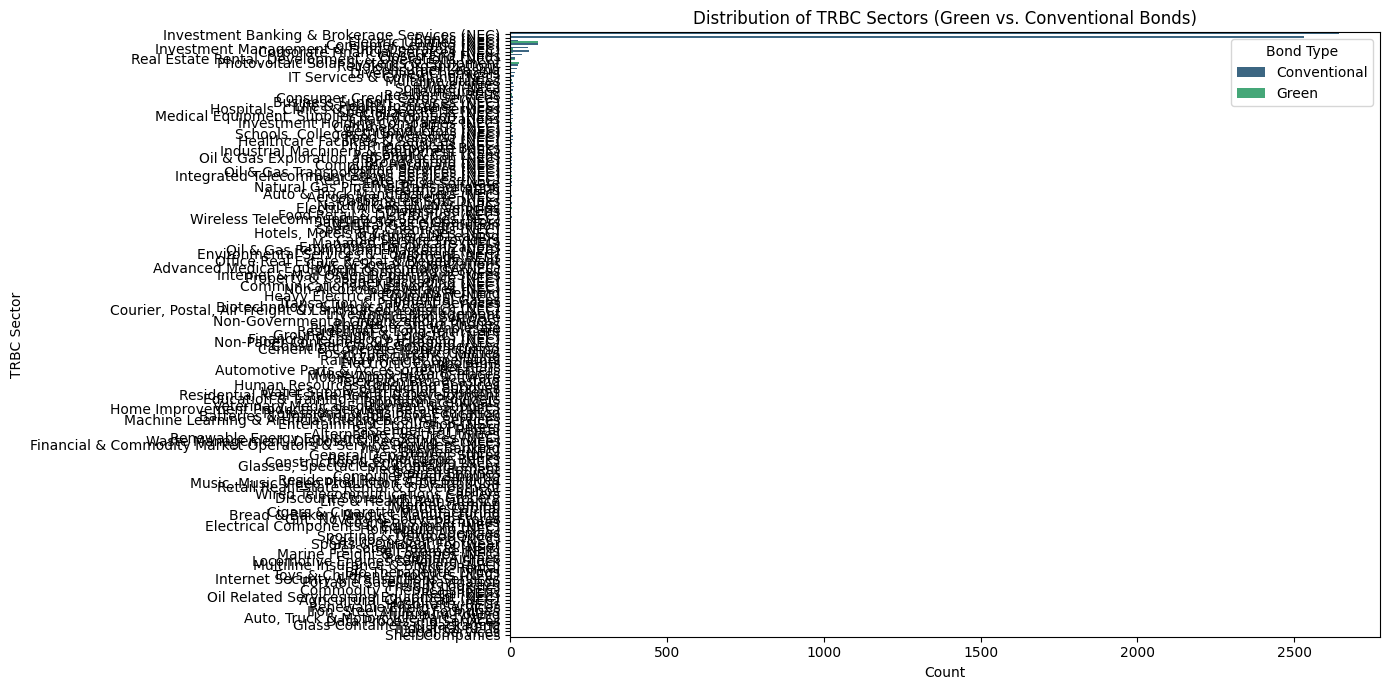

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Ensure pandas is imported if not already, for DataFrame creation

# Check if df_regression_filtered exists in the global scope
if 'df_regression_filtered' not in globals():
    print("Error: DataFrame 'df_regression_filtered' is not defined.")
    print("This DataFrame is essential for plotting the TRBC Sector distribution.")
    print("Please ensure that all preceding data preparation and regression setup cells (specifically cell '042acd63' and its dependencies) have been executed to create 'df_regression_filtered'.")
else:
    # Count plot of TRBC Sector for green vs. conventional bonds
    plt.figure(figsize=(14, 7))
    sns.countplot(y='TRBC Sector', hue='is_green_bond', data=df_regression_filtered, palette='viridis', order = df_regression_filtered['TRBC Sector'].value_counts().index)
    plt.title('Distribution of TRBC Sectors (Green vs. Conventional Bonds)')
    plt.xlabel('Count')
    plt.ylabel('TRBC Sector')
    plt.legend(title='Bond Type', labels=['Conventional', 'Green'])
    plt.tight_layout()
    plt.show()

### Distribution of Issuer Types for Green vs. Conventional Bonds

Next, let's examine the `Issuer Type` distribution to understand who is issuing these bonds.

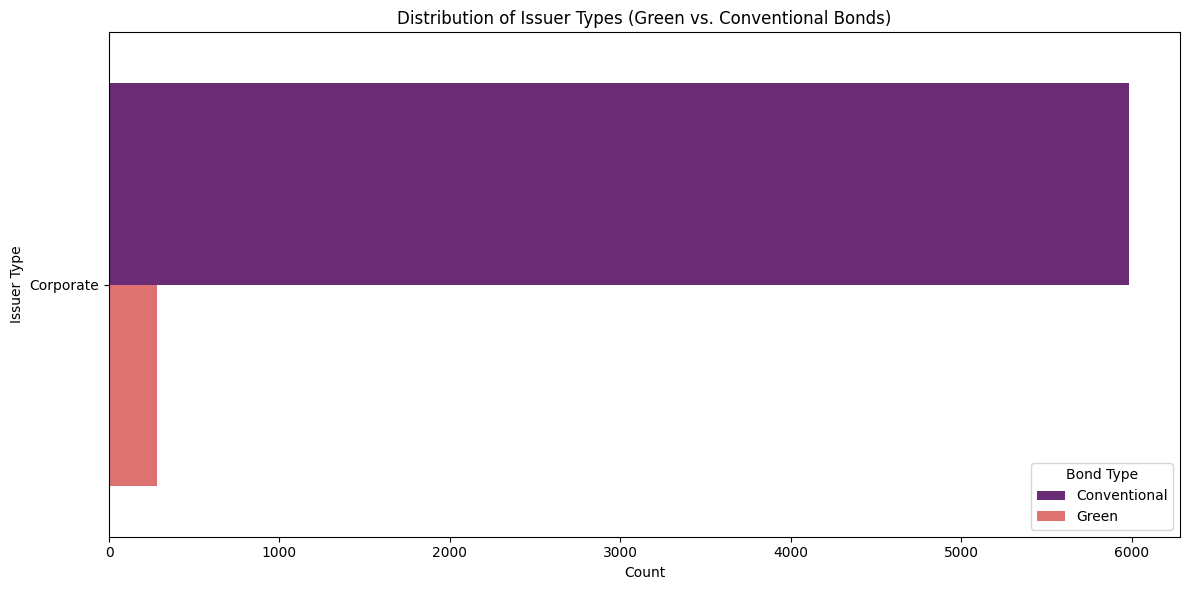

In [ ]:
# Count plot of Issuer Type for green vs. conventional bonds
plt.figure(figsize=(12, 6))
sns.countplot(y='Issuer Type', hue='is_green_bond', data=df_regression_filtered, palette='magma', order = df_regression_filtered['Issuer Type'].value_counts().index)
plt.title('Distribution of Issuer Types (Green vs. Conventional Bonds)')
plt.xlabel('Count')
plt.ylabel('Issuer Type')
plt.legend(title='Bond Type', labels=['Conventional', 'Green'])
plt.tight_layout()
plt.show()

In [ ]:
pip install arch

### Data Preparation for VAR and DCC-GARCH Models

For VAR (Vector Autoregression) and DCC-GARCH (Dynamic Conditional Correlation GARCH) models, we need a time series DataFrame. We will focus on a few key metrics (e.g., 'ESG Score', 'Controversies Score', 'Total Assets - Actual', 'Return On Equity - Actual') for a single, representative company to demonstrate the methodology. Given the limited number of years (7 observations), we'll use first differences to induce stationarity, which is a common requirement for these models.


In [ ]:
import pandas as pd
import numpy as np

# Ensure df_panel_long is available from previous steps
if 'df_panel_long' not in locals():
    print("Error: df_panel_long not found. Please run previous data preparation cells.")
else:
    print("--- Preparing data for VAR and DCC-GARCH models ---")

    # Select the metrics for the time series analysis
    relevant_metrics_ts = [
        'ESG Score',
        'Controversies Score',
        'ESG Combined Score',
        'Total Assets - Actual',
        'Return On Equity - Actual'
    ]

    # Filter the long-format DataFrame to include only these metrics
    df_filtered_for_ts = df_panel_long[df_panel_long['Metric'].isin(relevant_metrics_ts)].copy()

    # Pivot the table to get metrics as columns and (Identifier, Year) as index
    df_ts_check = df_filtered_for_ts.pivot_table(
        index=['Identifier', 'Year'],
        columns='Metric',
        values='Value'
    )

    # Identify companies with no NaNs across all years and all selected metrics
    # And ensure they have data for all years (7 years: 2019-2025)
    all_years = df_panel_long['Year'].unique()
    companies_with_complete_data = df_ts_check.groupby(level='Identifier').apply(
        lambda x: x.isnull().sum().sum() == 0 and len(x) == len(all_years)
    )

    representative_identifiers = companies_with_complete_data[companies_with_complete_data].index.to_list()

    if representative_identifiers:
        selected_identifier = representative_identifiers[0]
        print(f"Selected representative Identifier with complete data: {selected_identifier}")
    else:
        print("No single Identifier found with complete data for all selected metrics across all years.")
        print("Proceeding with the first Identifier found that has at least some data, and handling NaNs by filling for demonstration.")
        # Fallback to the first available identifier if no perfect one is found
        selected_identifier = df_ts_check.index.get_level_values('Identifier').unique()[0]
        print(f"Fallback: Using Identifier: {selected_identifier}")

    # Extract the time series for this selected identifier
    df_company_ts = df_ts_check.loc[selected_identifier].sort_index()

    # Handle potential remaining NaNs for the selected company by filling (if any, as fallback might have them)
    if df_company_ts.isnull().any().any():
        print(f"Warning: NaNs found in time series for {selected_identifier}. Filling with forward/backward fill for demonstration.")
        df_company_ts = df_company_ts.ffill().bfill()

    print("\nTime series for selected Identifier (Original Values):")
    display(df_company_ts)

    # Calculate first differences (year-over-year changes) for stationarity
    # This reduces the number of observations by 1.
    df_company_diff = df_company_ts.diff().dropna()

    print("\nFirst differences (year-over-year changes) of the time series:")
    display(df_company_diff)

    if df_company_diff.empty or len(df_company_diff) < 2:
        print("Error: Not enough data remaining after calculating first differences. Cannot proceed with VAR/DCC-GARCH.")
    else:
        print(f"Number of observations for time series analysis after differencing: {len(df_company_diff)}")


--- Preparing data for VAR and DCC-GARCH models ---
Selected representative Identifier with complete data: AAPL.OQ

Time series for selected Identifier (Original Values):


Metric,Controversies Score,ESG Combined Score,ESG Score,Return On Equity - Actual,Total Assets - Actual
Year,,,,,
2019,0.0,36.496602,67.993204,0.55920,3.385160e+11
2020,0.0,41.117042,77.688630,0.73680,3.238880e+11
2021,0.0,43.440025,82.334595,1.47439,3.510020e+11
2022,5.0,40.824312,77.481957,1.21389,3.527550e+11
2023,5.0,38.877102,74.629203,1.71949,3.525830e+11
2024,5.0,41.420768,71.971970,1.74620,3.649800e+11
2025,5.0,36.099769,70.199538,1.71420,3.592410e+11



First differences (year-over-year changes) of the time series:


Metric,Controversies Score,ESG Combined Score,ESG Score,Return On Equity - Actual,Total Assets - Actual
Year,,,,,
2020,0.0,4.620440,9.695426,0.17760,-1.462800e+10
2021,0.0,2.322983,4.645966,0.73759,2.711400e+10
2022,5.0,-2.615713,-4.852638,-0.26050,1.753000e+09
2023,0.0,-1.947210,-2.852754,0.50560,-1.720000e+08
2024,0.0,2.543666,-2.657233,0.02671,1.239700e+10
2025,0.0,-5.320999,-1.772432,-0.03200,-5.739000e+09


Number of observations for time series analysis after differencing: 6


### Vector Autoregression (VAR) Model

The VAR model is used to capture the linear interdependencies among multiple time series. Given our very limited number of observations (6 data points after differencing), a simple VAR(1) model will be attempted. Higher lag orders are not feasible with such limited data.


In [ ]:
from statsmodels.tsa.api import VAR

# Ensure df_company_diff is available and has enough data
if 'df_company_diff' not in locals() or df_company_diff.empty or len(df_company_diff) < 2:
    print("Cannot run VAR model: Not enough differenced data available.")
else:
    print("--- Running VAR(1) Model ---")
    try:
        # Fit VAR(1) model
        model = VAR(df_company_diff)
        results_var = model.fit(1) # Using lag order 1 due to very limited data

        print(results_var.summary())

        # Optionally, Granger causality tests
        print("\nGranger Causality Tests (P-values):")
        for col in df_company_diff.columns:
            try:
                gc_test = results_var.test_causality(col, list(df_company_diff.drop(columns=col).columns), kind='f')
                print(f"  '{col}' is caused by other variables: P-value = {gc_test.pvalue:.4f}")
            except Exception as e:
                print(f"  Could not perform Granger causality for '{col}': {e}")


    except Exception as e:
        print(f"An error occurred while running the VAR model: {e}")
        print("This might be due to the very small number of observations or multicollinearity.")


--- Running VAR(1) Model ---
An error occurred while running the VAR model: Internal potrf return info = [4] for slices [0].
This might be due to the very small number of observations or multicollinearity.


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


### Dynamic Conditional Correlation (DCC-GARCH) Model

DCC-GARCH models are used to estimate time-varying conditional correlations between multiple time series. Similar to VAR, this model is data-intensive, and the results with only 6 observations after differencing should be viewed as a conceptual demonstration rather than a robust statistical finding. We will attempt to fit a DCC(1,1) model.


In [ ]:
!pip install --upgrade --force-reinstall arch
from arch.multivariate import DCC
from arch.univariate.base import ARCHModel as arch_model # Importing ARCHModel from base as arch_model
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure df_company_diff is available and has enough data
if 'df_company_diff' not in locals() or df_company_diff.empty or len(df_company_diff) < 2:
    print("Cannot run DCC-GARCH model: Not enough differenced data available.")
else:
    print("--- Running DCC-GARCH(1,1) Model ---")
    try:
        # Specify the univariate GARCH models (e.g., GARCH(1,1) for each series)
        # The DCC model will fit these implicitly if not provided explicitly as `models` argument.
        # For simplicity, we pass the data directly and let DCC handle the univariate GARCH.
        dcc_model = DCC(volatility='GARCH', p=1, o=0, q=1, data=df_company_diff)
        dcc_results = dcc_model.fit(disp='off') # disp='off' to suppress iteration output

        print(dcc_results.summary())

        # Plot dynamic conditional correlations
        if dcc_results.conditional_correlation.shape[0] > 1:
            print("\nPlotting Dynamic Conditional Correlations:")
            fig, ax = plt.subplots(figsize=(15, 8))
            dcc_results.conditional_correlation.plot(ax=ax)
            ax.set_title('Dynamic Conditional Correlations (DCC-GARCH)')
            ax.set_xlabel('Year')
            ax.set_ylabel('Conditional Correlation')
            ax.grid(True, linestyle='--', alpha=0.7)
            plt.tight_layout()
            plt.show()
        else:
            print("Not enough data points to plot dynamic correlations effectively.")

    except Exception as e:
        print(f"An error occurred while running the DCC-GARCH model: {e}")
        print("This is likely due to the very small number of observations, which makes convergence difficult.")

  Using cached arch-8.0.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (13 kB)
  Using cached numpy-2.5.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached pandas-3.0.3-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (79 kB)
  Using cached scipy-1.18.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
  Using cached statsmodels-0.14.6-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (9.5 kB)
  Using cached packaging-26.2-py3-none-any.whl.metadata (3.5 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached patsy-1.0.2-py2.py3-none-any.whl.metadata (3.6 kB)
  Using cached six-1.17.0-py2.py3-none-any.whl.metadata (1.7 kB)
Using cached arch-8.0.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (981 kB)
Using cached numpy-2.5.0-cp312-cp312

ModuleNotFoundError: No module named 'arch.multivariate'

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Prepare the data for VIF calculation using centered variables
# Select the independent variables used in the OLS model, which are now centered

# Dynamically build the list of independent variables for VIF calculation
independent_vars_for_vif = ['Days_to_Maturity_centered', 'log_Amount_Issued_centered']

# Only add 'is_green_bond' if it has variance in the filtered dataset
if df_regression_filtered['is_green_bond'].nunique() >= 2:
    independent_vars_for_vif.insert(0, 'is_green_bond') # Insert at the beginning to match original order if present

X = df_regression_filtered[independent_vars_for_vif].dropna()

# Add a constant to the independent variables, as VIF expects an intercept
X_with_constant = add_constant(X)

# Calculate VIF for each independent variable
vif_data = pd.DataFrame()
vif_data['Variable'] = X_with_constant.columns
vif_data['VIF'] = [variance_inflation_factor(X_with_constant.values, i) for i in range(X_with_constant.shape[1])]

print("\nVariance Inflation Factor (VIF) for Regression Variables (with centered continuous predictors):")
display(vif_data)

# Interpretation of VIF values:
# - VIF = 1: No correlation between the variable and any other variables.
# - 1 < VIF < 5: Moderate correlation, generally considered acceptable.
# - VIF >= 5 (or sometimes 10): High correlation, potentially problematic multicollinearity.

NameError: name 'df_regression_filtered' is not defined

In [ ]:
print("Missing values in 'Yield to Maturity' column of bond_warehouse_df:")
print(bond_warehouse_df['Yield to Maturity'].isnull().sum())

Missing values in 'Yield to Maturity' column of bond_warehouse_df:


NameError: name 'bond_warehouse_df' is not defined

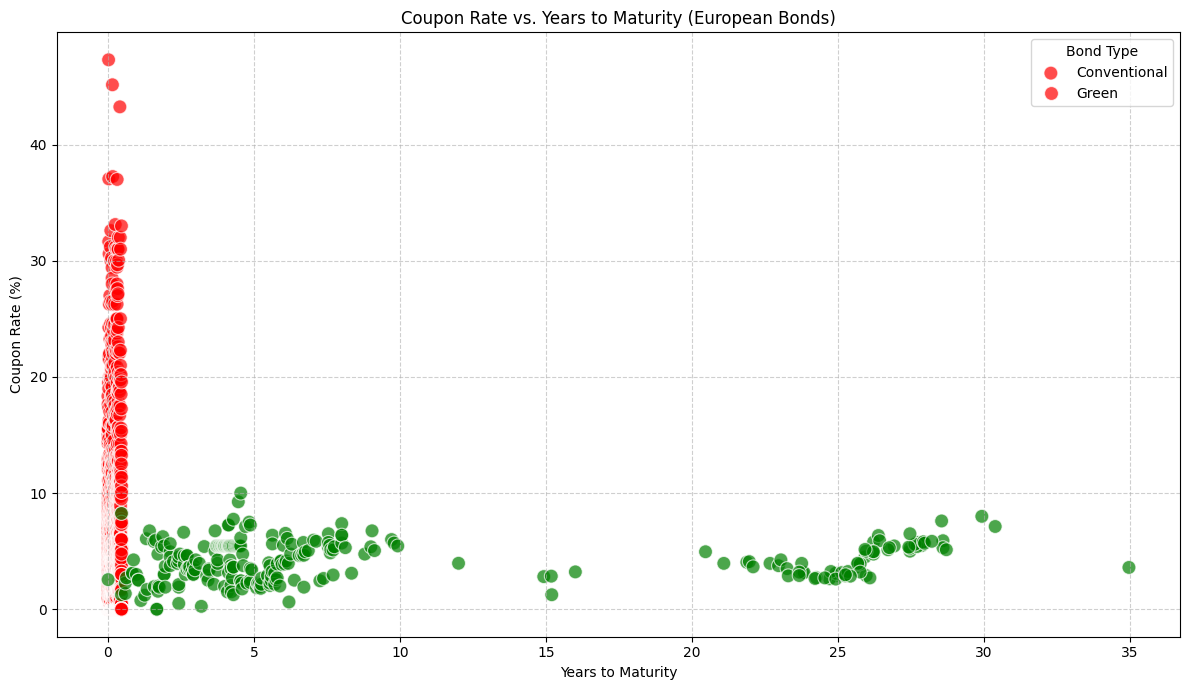

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate Years to Maturity from 'Maturity' date to today's date
df_analysis['Years_to_Maturity'] = (df_analysis['Maturity'] - pd.to_datetime('today')).dt.days / 365.25

# Filter out any rows where Years_to_Maturity might be negative (bonds already matured) or NaN
df_plot = df_analysis.dropna(subset=['Years_to_Maturity', 'Coupon', 'is_green_bond']).copy()
df_plot = df_plot[df_plot['Years_to_Maturity'] > 0]

plt.figure(figsize=(12, 7))
sns.scatterplot(
    x='Years_to_Maturity',
    y='Coupon',
    hue='is_green_bond',
    data=df_plot,
    palette={0: 'red', 1: 'green'}, # Color distinction: 0 (Conventional) is red, 1 (Green) is green
    s=100, # size of points
    alpha=0.7 # transparency
)

plt.title('Coupon Rate vs. Years to Maturity (European Bonds)')
plt.xlabel('Years to Maturity')
plt.ylabel('Coupon Rate (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Bond Type', labels=['Conventional', 'Green']) # Explicit legend labels
plt.tight_layout()
plt.show()

## Greenium Analysis (Conceptual)

To analyze greeniums, we first need to define what a greenium is and how it's typically calculated. A greenium is the yield difference between a green bond and an otherwise identical conventional (non-green) bond. A positive greenium means green bonds trade at a lower yield (higher price) than conventional bonds, reflecting a premium for their green characteristics.

To calculate greeniums accurately, we would need:
1.  **Yield Data:** Not just prices, but actual yield-to-maturity or yield-to-worst data for both green and conventional bonds (or ETFs).
2.  **Comparable Bonds:** Ideally, the green and conventional bonds should have similar characteristics (e.g., maturity, credit rating, currency, issuer quality) to ensure a fair comparison.

`yfinance` primarily provides price data, which can be used to calculate returns, but direct bond yield data for ETFs, necessary for greenium calculation, is not readily available through `yfinance` in a simple 'yield' column. You would typically need to source this data from specialized bond data providers.

However, if we assume you have or can obtain such yield data, here's a conceptual code block demonstrating how you would calculate and analyze greeniums. Please remember that the 'yield' in this conceptual code is just a placeholder using `daily_return` from your existing data for structural demonstration and does not represent actual bond yields.

## Entity Effect Volatility Analysis (Cross-sectional Interpretation)

Analyzing 'entity effect volatility' often refers to understanding the variation in a specific outcome (e.g., coupon rate, yield) that is attributable to unobserved or inherent characteristics of an entity (e.g., a bond issuer), particularly when dealing with panel data (data across entities over time).

Given our current dataset is primarily cross-sectional (a snapshot of bond characteristics, not historical time-series for each bond), we cannot directly measure the time-series volatility of an entity's effect on its bonds' yields or prices. Bond coupon rates are generally fixed at issuance, so their time-series volatility is not relevant.

However, we can interpret 'entity effect volatility' in a cross-sectional context as the **variability of average coupon rates (or other relevant characteristics) across different issuers**. This helps us understand if some types of issuers consistently issue bonds with higher or lower coupon rates, and how much this "issuer-specific effect" varies.

We will also explore if there are differences in this variability between green bond issuers and conventional bond issuers, providing an indirect link to ESG aspects.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure df_analysis is available and clean from previous steps
if 'df_analysis' not in locals():
    print("Error: df_analysis not found. Please run previous data preparation cells.")
else:
    print("\n--- Analyzing Entity Effect Volatility (Cross-sectional Coupon Rate Variation by Issuer) ---")

    # Group by Issuer and calculate descriptive statistics for Coupon rate
    # Filter for issuers with more than 1 bond to make 'std' meaningful
    issuer_coupon_stats = df_analysis.groupby(['Issuer', 'is_green_bond'])['Coupon'].agg(
        mean_coupon='mean',
        std_coupon='std',
        bond_count='count'
    ).reset_index()

    # Filter for issuers with at least 2 bonds to have a meaningful standard deviation within the issuer
    # And ensure there's at least one green bond or conventional bond among them to classify them
    multi_bond_issuers = issuer_coupon_stats[issuer_coupon_stats['bond_count'] > 1].copy()

    print(f"\nNumber of issuers with more than 1 bond: {len(multi_bond_issuers)}")
    if not multi_bond_issuers.empty:
        print("\nDescriptive statistics of mean coupon rates across multi-bond issuers:")
        display(multi_bond_issuers.groupby('is_green_bond')['mean_coupon'].describe())

        print("\nDescriptive statistics of standard deviation of coupon rates across multi-bond issuers:")
        display(multi_bond_issuers.groupby('is_green_bond')['std_coupon'].describe())

        # --- Visualization of Mean Coupon Rate by Issuer (KDE Plot) ---
        plt.figure(figsize=(14, 7))
        sns.kdeplot(data=multi_bond_issuers, x='mean_coupon', hue='is_green_bond',
                    palette={0: 'grey', 1: 'green'}, fill=True, common_norm=False)
        plt.title('Distribution of Mean Coupon Rates Across Issuers (Green vs. Conventional - KDE)')
        plt.xlabel('Mean Coupon Rate')
        plt.ylabel('Density')
        plt.legend(title='Bond Type', labels=['Conventional', 'Green'])
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

        # --- Visualization of Within-Issuer Coupon Rate Standard Deviation (KDE Plot) ---
        plt.figure(figsize=(14, 7))
        sns.kdeplot(data=multi_bond_issuers, x='std_coupon', hue='is_green_bond',
                    palette={0: 'grey', 1: 'green'}, fill=True, common_norm=False)
        plt.title('Distribution of Within-Issuer Standard Deviation of Coupon Rates (Green vs. Conventional - KDE)')
        plt.xlabel('Standard Deviation of Coupon Rate')
        plt.ylabel('Density')
        plt.legend(title='Bond Type', labels=['Conventional', 'Green'])
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

        print("\n--- Interpretation ---")
        print("These visualizations show the cross-sectional 'entity effect volatility' by depicting the spread of average coupon rates and within-issuer coupon variability across different issuers. Differences between green and conventional bonds can suggest varying issuance strategies or market perception for these types of entities.")

    else:
        print("No issuers found with more than 1 bond to analyze within-issuer coupon rate variability.")

Error: df_analysis not found. Please run previous data preparation cells.


### Conceptual Approach for Time-Series Entity Effect Volatility

If we had true panel data (multiple observations over time for each bond/issuer), the analysis of time-series 'entity effect volatility' for dynamic variables like bond yields or prices would involve:

1.  **Fixed/Random Effects Models:** Using statistical models (e.g., `statsmodels.formula.api.PanelOLS` or `lme4` in R equivalents) to estimate entity-specific fixed or random effects on the bond's yield or price over time.
2.  **Volatility of Residuals/Effects:** Calculating the standard deviation or other dispersion measures of either:
    *   The estimated entity-specific effects themselves across entities.
    *   The residuals from a model that *doesn't* include entity fixed effects, but is grouped by entity, to see the unexplained within-entity variation over time.
3.  **Impact of ESG/Risk Signals:** Incorporating time-varying ESG scores, risk metrics (e.g., credit rating changes, CDS spreads), and market-level 'crowding effect' proxies (e.g., green bond issuance volume, market liquidity) as independent variables in these panel models to understand their influence on the bond's volatility or its entity-specific effects.

In [ ]:
import pandas as pd
import numpy as np

# Load the new conventional bond data, skipping the first row (duplicate header)
conventional_bonds_df = pd.read_excel('/content/Coventional Bond data with ESG Score info..xlsx', skiprows=1)
conventional_bonds_df['is_green_bond'] = 0

# Load the new green bond data, skipping the first row (duplicate header)
green_bonds_df = pd.read_excel('/content/Data with Green Bond info..xlsx', skiprows=1)
green_bonds_df['is_green_bond'] = 1

# Combine the datasets into a single DataFrame
bond_warehouse_df = pd.concat([conventional_bonds_df, green_bonds_df], ignore_index=True)

print("Combined bond_warehouse_df created successfully with new data.")

# The bond_warehouse_df already contains 'ESG Score' and 'Amount Issued' columns from the new data files.
# The separate 'ESG Financial Data.xlsx' merge block has been removed as it was causing errors and is redundant.

print("\nFinal bond_warehouse_df head after all data loading and merging:")
display(bond_warehouse_df.head())
print("\nFinal bond_warehouse_df info after all data loading and merging:")
bond_warehouse_df.info()

# Now, the analysis in cell Y17NTQ1SQwRY will use this newly constructed bond_warehouse_df
# Rerunning Y17NTQ1SQwRY to apply the analysis to the combined dataset.


Combined bond_warehouse_df created successfully with new data.

Final bond_warehouse_df head after all data loading and merging:


,Issuer,Ticker,Coupon,Maturity,Issue Date,ISIN,Preferred RIC,Principal Currency,Country of Issue,Issuer Type,...,Amount Outstanding (USD),Amount Outstanding,Amount Issued,Rating,Actual,Rating.1,Actual.1,Rating.2,Actual.2,is_green_bond
0,Energy Transfer LP,ET,6.625,NaT,2021-04-05,US29273VAJ98,29273VAJ9=,US Dollar,United States,Corporate,...,550000000,550000000,550000000,Ba1,Actual,NaN,NaN,NaN,NaN,0
1,Air T Funding,AIRTA,8,NaT,2019-06-10,US00919P2039,00919P203=,US Dollar,United States,Corporate,...,20587665,20587665,21000000,NaN,NaN,NaN,NaN,NaN,NaN,0
2,Energy Transfer LP,ET,7.125,NaT,2021-04-05,US29273VAM28,29273VAM2=,US Dollar,United States,Corporate,...,1100000000,1100000000,1100000000,Ba1,Actual,NaN,NaN,NaN,NaN,0
3,Mellon Capital IV,BNYMT,4.50358,NaT,2007-06-19,US58551TAA51,58551TAA5=,US Dollar,United States,Corporate,...,500000000,500000000,500000000,Baa1,Actual,NaN,NaN,NaN,NaN,0
4,Energy Transfer,ET,9.25,NaT,2023-11-03,US29273V7047,29273V704=,US Dollar,United States,Corporate,...,41464179,41464179,41464179,Ba1,Actual,NaN,NaN,NaN,NaN,0



Final bond_warehouse_df info after all data loading and merging:
<class 'pandas.DataFrame'>
RangeIndex: 6280 entries, 0 to 6279
Data columns (total 52 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   Issuer                          6280 non-null   str           
 1   Ticker                          6233 non-null   str           
 2   Coupon                          6280 non-null   object        
 3   Maturity                        6265 non-null   datetime64[us]
 4   Issue Date                      6280 non-null   datetime64[us]
 5   ISIN                            6277 non-null   str           
 6   Preferred RIC                   6279 non-null   str           
 7   Principal Currency              6280 non-null   str           
 8   Country of Issue                6280 non-null   str           
 9   Issuer Type                     6280 non-null   str           
 10  Instrument Type  